# **Data Preparation and Analysis of Major Crime Indicator Dataset**

 **Summary:**

**1. Data preparation by report date**

*   Select records for 2021 to 2024 and sort by REPORT_DATE
*   Remove a partial week at the beginning of dataset (new week starts from Monday)
*   Create column: REPORT_MONTH_SEQ
*   Create column: REPORT_DAY_SEQ
*   Create column: REPORT_WEEK_SEQ
*   Drop rows where neighborhood profile is unknown
*   Group crime counts by HOOD_158, WEEK_SEQ
*   Group crime counts by HOOD_158, WEEK_SEQ, MCI_CATEGORY

**2. Data preparation by occurence date**

*   Select records for 2021 to 2024 and sort by OCC_DATE
*   Remove a partial week at the beginning of dataset (new week starts from Monday)
*   Create column: OCC_MONTH_SEQ
*   Create column: OCC_DAY_SEQ
*   Create column: OCC_WEEK_SEQ
*   Drop rows where neighborhood profile is unknown
*   Group crime counts by HOOD_158, OCC_WEEK_SEQ
*   Group crime counts by HOOD_158, OCC_WEEK_SEQ, OCC_MCI_CATEGORY

**3. Create a column: HOLIDAY and anlysis of holiday vs non holiday by occurence date**

**4. Create a column: WEEKEND and anlysis of weekday vs weekends by occurence date**

**5. Anlysis of day time vs night time by occurence date**

**6. Anlysis of PREMISES_TYPE by occurence date**

**7. Anlysis of LOCATION_TYPE by occurence date**

**8. Anlysis of OFFENCE by occurence date**

**9. Analysis by report date**

**10. Pilot analysis by joint Major Crime Indicator with neibourhood profile**



In [ ]:
# Dynamically choose file from repository
from google.colab import files
uploaded = files.upload()

Saving neighbourhood-profiles-2021-158-model(1).xlsx to neighbourhood-profiles-2021-158-model(1).xlsx
Saving Major_Crime_Indicators_Open_Data_-3805566126367379926.csv to Major_Crime_Indicators_Open_Data_-3805566126367379926.csv


In [ ]:
#Load the initial dataset into dataframe
import pandas as pd
import io

df = pd.read_csv('Major_Crime_Indicators_Open_Data_-3805566126367379926.csv')
df.shape

(430614, 31)

## **1. Data preparation by report date**

In [ ]:
# Make a copy of the original dataset for process data and keeping the original data integrity
df_mci = df.copy()
#Select records for years 2021 - 2024, sort by REPORT_DATE
df_mci = df_mci[(df_mci['REPORT_YEAR'] >= 2021) &
      (df_mci['REPORT_YEAR'] < 2025)]
df_mci.sort_values(by='REPORT_DATE', ascending=True)
df_mci.tail(10)

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,OFFENCE,MCI_CATEGORY,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y
420489,420490,GO-20242821061,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,22,...,Robbery With Weapon,Robbery,126,Dorset Park (126),126,Dorset Park (126),-79.273631,43.745996,-8.824700e+06,5.426218e+06
420490,420491,GO-20242819772,12/31/2024 5:00:00 AM,12/30/2024 5:00:00 AM,2024,December,31,366,Tuesday,18,...,Assault,Assault,108,Briar Hill-Belgravia (108),108,Briar Hill-Belgravia (108),-79.440599,43.701073,-8.843287e+06,5.419298e+06
420491,420492,GO-20242820426,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,20,...,Assault With Weapon,Assault,033,Clanton Park (33),033,Clanton Park (33),-79.449706,43.734062,-8.844301e+06,5.424380e+06
420492,420493,GO-20242814702,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,1,...,Theft Of Motor Vehicle,Auto Theft,002,Mount Olive-Silverstone-Jamestown (2),002,Mount Olive-Silverstone-Jamestown (2),-79.585776,43.750942,-8.859448e+06,5.426980e+06
420493,420494,GO-20242818725,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,15,...,Assault,Assault,074,North St.James Town (74),074,North St.James Town (74),-79.373767,43.667288,-8.835847e+06,5.414098e+06
420494,420495,GO-20242818725,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,15,...,Assault,Assault,074,North St.James Town (74),074,North St.James Town (74),-79.373767,43.667288,-8.835847e+06,5.414098e+06
420495,420496,GO-20242816566,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,12,...,Theft Over,Theft Over,009,Edenbridge-Humber Valley (9),009,Edenbridge-Humber Valley (9),-79.524582,43.672837,-8.852636e+06,5.414952e+06
420496,420497,GO-20242817087,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,14,...,B&E,Break and Enter,084,Little Portugal (84),084,Little Portugal (84),-79.423596,43.643234,-8.841394e+06,5.410397e+06
420497,420498,GO-20242818018,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,13,...,Assault,Assault,029,Maple Leaf (29),029,Maple Leaf (29),-79.478591,43.711185,-8.847516e+06,5.420856e+06
420498,420499,GO-20242815101,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,3,...,Theft Of Motor Vehicle,Auto Theft,078,Kensington-Chinatown (78),078,Kensington-Chinatown (78),-79.401983,43.647598,-8.838988e+06,5.411068e+06


In [ ]:
df_mci.shape

(173820, 31)

In [ ]:
df_mci[df_mci.REPORT_DOW.str.contains('Monday')].index[0]

np.int64(246904)

In [ ]:
last_index = df_mci[df_mci['REPORT_DOW'].str.contains('Sunday')].index[-1]
last_index

np.int64(420245)

In [ ]:
#Remove a partial week at the beginning of dataset (new week starts from Monday).
df_mci = df_mci.loc[(df_mci[df_mci.REPORT_DOW.str.contains('Monday')].index[0]) : df_mci[df_mci['REPORT_DOW'].str.contains('Sunday')].index[-1]]
df_mci.shape

(173342, 31)

In [ ]:
df_mci

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,OFFENCE,MCI_CATEGORY,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y
246904,246905,GO-202118735,1/4/2021 5:00:00 AM,12/27/2020 5:00:00 AM,2021,January,4,4,Monday,9,...,Theft Over,Theft Over,141,Golfdale-Cedarbrae-Woburn (141),137,Woburn (137),-79.205649,43.764062,-8.817132e+06,5.429003e+06
246905,246906,GO-202118735,1/4/2021 5:00:00 AM,12/27/2020 5:00:00 AM,2021,January,4,4,Monday,9,...,B&E,Break and Enter,141,Golfdale-Cedarbrae-Woburn (141),137,Woburn (137),-79.205649,43.764062,-8.817132e+06,5.429003e+06
246906,246907,GO-202115012,1/4/2021 5:00:00 AM,12/1/2020 5:00:00 AM,2021,January,4,4,Monday,14,...,B&E,Break and Enter,097,Yonge-St.Clair (97),097,Yonge-St.Clair (97),-79.392380,43.683934,-8.837919e+06,5.416660e+06
246907,246908,GO-20212356161,1/4/2021 5:00:00 AM,1/4/2021 5:00:00 AM,2021,January,4,4,Monday,6,...,Theft Of Motor Vehicle,Auto Theft,144,Morningside Heights (144),131,Rouge (131),-79.227042,43.834025,-8.819514e+06,5.439793e+06
246908,246909,GO-202118245,1/4/2021 5:00:00 AM,12/3/2020 5:00:00 AM,2021,January,4,4,Monday,13,...,B&E,Break and Enter,173,North Toronto (173),104,Mount Pleasant West (104),-79.394125,43.707598,-8.838114e+06,5.420303e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420241,420242,GO-20242806824,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,22,...,Assault,Assault,049,Bayview Woods-Steeles (49),049,Bayview Woods-Steeles (49),-79.383942,43.794515,-8.836980e+06,5.433698e+06
420242,420243,GO-20242807008,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,23,...,B&E,Break and Enter,128,Agincourt South-Malvern West (128),128,Agincourt South-Malvern West (128),-79.252186,43.789439,-8.822313e+06,5.432915e+06
420243,420244,GO-20242801710,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,4,...,Assault With Weapon,Assault,036,Newtonbrook West (36),036,Newtonbrook West (36),-79.419619,43.796317,-8.840952e+06,5.433976e+06
420244,420245,GO-20242807066,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,23,...,B&E,Break and Enter,144,Morningside Heights (144),131,Rouge (131),-79.177442,43.822902,-8.813993e+06,5.438077e+06


In [ ]:
#Replace month names with the corresponding int values (January =1, Feb = 2, etc.)
df_mci['REPORT_MONTH_SEQ'] = df_mci['REPORT_MONTH'].replace('January', 1).replace('February', 2).replace('March', 3).replace('April', 4).replace('May', 5).replace('June', 6).replace('July', 7).replace('August', 8).replace('September', 9).replace('October', 10).replace('November', 11).replace('December', 12)

/tmp/ipython-input-10-1020389931.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_mci['REPORT_MONTH_SEQ'] = df_mci['REPORT_MONTH'].replace('January', 1).replace('February', 2).replace('March', 3).replace('April', 4).replace('May', 5).replace('June', 6).replace('July', 7).replace('August', 8).replace('September', 9).replace('October', 10).replace('November', 11).replace('December', 12)


In [ ]:
#Create a column DAY_SEQ that keeps a sequential number of day since the starting date of analysis (i.e., from January 4, 2021)
from datetime import datetime
df_mci['DAY_SEQ'] = pd.to_datetime(df_mci["REPORT_MONTH_SEQ"].astype(str) + "/" + df_mci["REPORT_DAY"].astype(str) + "/" + df_mci["REPORT_YEAR"].astype(str))
df_mci['DAY_SEQ'] = (df_mci['DAY_SEQ'] - df_mci['DAY_SEQ'].iloc[0]).dt.days
df_mci

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y,REPORT_MONTH_SEQ,DAY_SEQ
246904,246905,GO-202118735,1/4/2021 5:00:00 AM,12/27/2020 5:00:00 AM,2021,January,4,4,Monday,9,...,141,Golfdale-Cedarbrae-Woburn (141),137,Woburn (137),-79.205649,43.764062,-8.817132e+06,5.429003e+06,1,0
246905,246906,GO-202118735,1/4/2021 5:00:00 AM,12/27/2020 5:00:00 AM,2021,January,4,4,Monday,9,...,141,Golfdale-Cedarbrae-Woburn (141),137,Woburn (137),-79.205649,43.764062,-8.817132e+06,5.429003e+06,1,0
246906,246907,GO-202115012,1/4/2021 5:00:00 AM,12/1/2020 5:00:00 AM,2021,January,4,4,Monday,14,...,097,Yonge-St.Clair (97),097,Yonge-St.Clair (97),-79.392380,43.683934,-8.837919e+06,5.416660e+06,1,0
246907,246908,GO-20212356161,1/4/2021 5:00:00 AM,1/4/2021 5:00:00 AM,2021,January,4,4,Monday,6,...,144,Morningside Heights (144),131,Rouge (131),-79.227042,43.834025,-8.819514e+06,5.439793e+06,1,0
246908,246909,GO-202118245,1/4/2021 5:00:00 AM,12/3/2020 5:00:00 AM,2021,January,4,4,Monday,13,...,173,North Toronto (173),104,Mount Pleasant West (104),-79.394125,43.707598,-8.838114e+06,5.420303e+06,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420241,420242,GO-20242806824,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,22,...,049,Bayview Woods-Steeles (49),049,Bayview Woods-Steeles (49),-79.383942,43.794515,-8.836980e+06,5.433698e+06,12,1455
420242,420243,GO-20242807008,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,23,...,128,Agincourt South-Malvern West (128),128,Agincourt South-Malvern West (128),-79.252186,43.789439,-8.822313e+06,5.432915e+06,12,1455
420243,420244,GO-20242801710,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,4,...,036,Newtonbrook West (36),036,Newtonbrook West (36),-79.419619,43.796317,-8.840952e+06,5.433976e+06,12,1455
420244,420245,GO-20242807066,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,23,...,144,Morningside Heights (144),131,Rouge (131),-79.177442,43.822902,-8.813993e+06,5.438077e+06,12,1455


In [ ]:
# Create a column WEEK_SEQ that keeps a sequential number of a week since the starting date of analysis (i.e., from January 4, 2021)
df_mci['WEEK_SEQ'] = (df_mci['DAY_SEQ'] // 7) + 1
df_mci.head(5)

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y,REPORT_MONTH_SEQ,DAY_SEQ,WEEK_SEQ
246904,246905,GO-202118735,1/4/2021 5:00:00 AM,12/27/2020 5:00:00 AM,2021,January,4,4,Monday,9,...,Golfdale-Cedarbrae-Woburn (141),137,Woburn (137),-79.205649,43.764062,-8.817132e+06,5.429003e+06,1,0,1
246905,246906,GO-202118735,1/4/2021 5:00:00 AM,12/27/2020 5:00:00 AM,2021,January,4,4,Monday,9,...,Golfdale-Cedarbrae-Woburn (141),137,Woburn (137),-79.205649,43.764062,-8.817132e+06,5.429003e+06,1,0,1
246906,246907,GO-202115012,1/4/2021 5:00:00 AM,12/1/2020 5:00:00 AM,2021,January,4,4,Monday,14,...,Yonge-St.Clair (97),097,Yonge-St.Clair (97),-79.392380,43.683934,-8.837919e+06,5.416660e+06,1,0,1
246907,246908,GO-20212356161,1/4/2021 5:00:00 AM,1/4/2021 5:00:00 AM,2021,January,4,4,Monday,6,...,Morningside Heights (144),131,Rouge (131),-79.227042,43.834025,-8.819514e+06,5.439793e+06,1,0,1
246908,246909,GO-202118245,1/4/2021 5:00:00 AM,12/3/2020 5:00:00 AM,2021,January,4,4,Monday,13,...,North Toronto (173),104,Mount Pleasant West (104),-79.394125,43.707598,-8.838114e+06,5.420303e+06,1,0,1


In [ ]:
# Drop rows where neighborhood profile is unknown
df_mci.drop(df_mci[df_mci['HOOD_158'].str.contains('NSA')].index, inplace = True)
df_mci

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y,REPORT_MONTH_SEQ,DAY_SEQ,WEEK_SEQ
246904,246905,GO-202118735,1/4/2021 5:00:00 AM,12/27/2020 5:00:00 AM,2021,January,4,4,Monday,9,...,Golfdale-Cedarbrae-Woburn (141),137,Woburn (137),-79.205649,43.764062,-8.817132e+06,5.429003e+06,1,0,1
246905,246906,GO-202118735,1/4/2021 5:00:00 AM,12/27/2020 5:00:00 AM,2021,January,4,4,Monday,9,...,Golfdale-Cedarbrae-Woburn (141),137,Woburn (137),-79.205649,43.764062,-8.817132e+06,5.429003e+06,1,0,1
246906,246907,GO-202115012,1/4/2021 5:00:00 AM,12/1/2020 5:00:00 AM,2021,January,4,4,Monday,14,...,Yonge-St.Clair (97),097,Yonge-St.Clair (97),-79.392380,43.683934,-8.837919e+06,5.416660e+06,1,0,1
246907,246908,GO-20212356161,1/4/2021 5:00:00 AM,1/4/2021 5:00:00 AM,2021,January,4,4,Monday,6,...,Morningside Heights (144),131,Rouge (131),-79.227042,43.834025,-8.819514e+06,5.439793e+06,1,0,1
246908,246909,GO-202118245,1/4/2021 5:00:00 AM,12/3/2020 5:00:00 AM,2021,January,4,4,Monday,13,...,North Toronto (173),104,Mount Pleasant West (104),-79.394125,43.707598,-8.838114e+06,5.420303e+06,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420241,420242,GO-20242806824,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,22,...,Bayview Woods-Steeles (49),049,Bayview Woods-Steeles (49),-79.383942,43.794515,-8.836980e+06,5.433698e+06,12,1455,208
420242,420243,GO-20242807008,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,23,...,Agincourt South-Malvern West (128),128,Agincourt South-Malvern West (128),-79.252186,43.789439,-8.822313e+06,5.432915e+06,12,1455,208
420243,420244,GO-20242801710,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,4,...,Newtonbrook West (36),036,Newtonbrook West (36),-79.419619,43.796317,-8.840952e+06,5.433976e+06,12,1455,208
420244,420245,GO-20242807066,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,23,...,Morningside Heights (144),131,Rouge (131),-79.177442,43.822902,-8.813993e+06,5.438077e+06,12,1455,208


In [ ]:
# Group by HOOD_158 and WEEK_SEQ, save results in CSV file
df_mci_cat = df_mci.copy()
df_mci_cat['HOOD_158'] = pd.Categorical(df_mci_cat.HOOD_158)
df_mci_cat['WEEK_SEQ'] = pd.Categorical(df_mci_cat.WEEK_SEQ)
df_mci_cat['MCI_CATEGORY'] = pd.Categorical(df_mci_cat.MCI_CATEGORY)
grouped_counts_all_crimes_with_zeros = df_mci_cat.groupby(['HOOD_158', 'WEEK_SEQ']).count()
grouped_counts_all_crimes_with_zeros = grouped_counts_all_crimes_with_zeros.reset_index()
grouped_counts_all_crimes_with_zeros_short = grouped_counts_all_crimes_with_zeros.filter(['HOOD_158','WEEK_SEQ','EVENT_UNIQUE_ID'], axis=1)
grouped_counts_all_crimes_with_zeros_short = grouped_counts_all_crimes_with_zeros_short.rename(columns={'EVENT_UNIQUE_ID': 'Crime_counts'})
grouped_counts_all_crimes_with_zeros_short.to_csv('grouped_counts_all_crimes_with_zeros_short.csv', index=False)
grouped_counts_all_crimes_with_zeros_short.info()

/tmp/ipython-input-14-2377144287.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_counts_all_crimes_with_zeros = df_mci_cat.groupby(['HOOD_158', 'WEEK_SEQ']).count()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32864 entries, 0 to 32863
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   HOOD_158      32864 non-null  category
 1   WEEK_SEQ      32864 non-null  category
 2   Crime_counts  32864 non-null  int64   
dtypes: category(2), int64(1)
memory usage: 400.3 KB


In [ ]:
categories_crime = df_mci_cat['MCI_CATEGORY'].unique()

In [ ]:
grouped_counts_all_crimes_with_zeros_short

,HOOD_158,WEEK_SEQ,Crime_counts
0,001,1,19
1,001,2,11
2,001,3,12
3,001,4,20
4,001,5,12
...,...,...,...
32859,174,204,6
32860,174,205,5
32861,174,206,5
32862,174,207,2


In [ ]:
# Group by HOOD_158, WEEK_SEQ and MCI_CATEGORY, save results in CSV file
grouped_counts_mci_categories_with_zeros = df_mci_cat.groupby(['HOOD_158', 'WEEK_SEQ', 'MCI_CATEGORY'], observed=False).count()
grouped_counts_mci_categories_with_zeros = grouped_counts_mci_categories_with_zeros.reset_index()
grouped_counts_mci_categories_with_zeros_short = grouped_counts_mci_categories_with_zeros.filter(['HOOD_158','WEEK_SEQ','MCI_CATEGORY', 'EVENT_UNIQUE_ID'], axis=1)
grouped_counts_mci_categories_with_zeros_short = grouped_counts_mci_categories_with_zeros_short.rename(columns={'EVENT_UNIQUE_ID': 'Crime_counts'})
grouped_counts_mci_categories_with_zeros_short.to_csv('grouped_counts_mci_categories_with_zeros_short.csv', index=False)
grouped_counts_mci_categories_with_zeros_short.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164320 entries, 0 to 164319
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   HOOD_158      164320 non-null  category
 1   WEEK_SEQ      164320 non-null  category
 2   MCI_CATEGORY  164320 non-null  category
 3   Crime_counts  164320 non-null  int64   
dtypes: category(3), int64(1)
memory usage: 2.1 MB


In [ ]:
grouped_counts_mci_categories_with_zeros_short

,HOOD_158,WEEK_SEQ,MCI_CATEGORY,Crime_counts
0,001,1,Assault,5
1,001,1,Auto Theft,9
2,001,1,Break and Enter,3
3,001,1,Robbery,0
4,001,1,Theft Over,2
...,...,...,...,...
164315,174,208,Assault,2
164316,174,208,Auto Theft,0
164317,174,208,Break and Enter,0
164318,174,208,Robbery,0


## **2. Data preparation by occurence date**

In [ ]:
# Copy original dataset
df_mci_occ = df.copy()

# Convert 'OCC_DATE' to datetime objects
df_mci_occ['OCC_DATE'] = pd.to_datetime(df_mci_occ['OCC_DATE'], errors='coerce')

# Filter records for years 2021 - 2024 based on the year of OCC_DATE
df_mci_occ = df_mci_occ[(df_mci_occ['OCC_DATE'].dt.year >= 2021) &
      (df_mci_occ['OCC_DATE'].dt.year < 2025)]

df_mci_occ.sort_values(by='OCC_DATE', ascending=True)
df_mci_occ.tail(10)

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,OFFENCE,MCI_CATEGORY,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y
430363,430364,GO-2025650048,3/29/2025 4:00:00 AM,2024-07-01 04:00:00,2025,March,29,88,Saturday,3,...,Assault With Weapon,Assault,043,Victoria Village (43),043,Victoria Village (43),-79.303714,43.724620,-8.828049e+06,5.422925e+06
430375,430376,GO-2025650048,3/29/2025 4:00:00 AM,2024-07-01 04:00:00,2025,March,29,88,Saturday,3,...,Assault With Weapon,Assault,043,Victoria Village (43),043,Victoria Village (43),-79.303714,43.724620,-8.828049e+06,5.422925e+06
430379,430380,GO-2025650600,3/29/2025 4:00:00 AM,2023-09-01 04:00:00,2025,March,29,88,Saturday,2,...,Assault,Assault,169,Bay-Cloverhill (169),076,Bay Street Corridor (76),-79.383362,43.662025,-8.836915e+06,5.413288e+06
430380,430381,GO-2025653672,3/29/2025 4:00:00 AM,2023-06-01 04:00:00,2025,March,29,88,Saturday,14,...,Assault With Weapon,Assault,006,Kingsview Village-The Westway (6),006,Kingsview Village-The Westway (6),-79.552151,43.695790,-8.855705e+06,5.418485e+06
430388,430389,GO-2025650600,3/29/2025 4:00:00 AM,2023-09-01 04:00:00,2025,March,29,88,Saturday,2,...,Assault Bodily Harm,Assault,169,Bay-Cloverhill (169),076,Bay Street Corridor (76),-79.383362,43.662025,-8.836915e+06,5.413288e+06
430405,430406,GO-20252286226,3/30/2025 4:00:00 AM,2022-11-23 05:00:00,2025,March,30,89,Sunday,16,...,Theft Over,Theft Over,170,Yonge-Bay Corridor (170),076,Bay Street Corridor (76),-79.381320,43.651162,-8.836688e+06,5.411616e+06
430510,430511,GO-2025671642,3/31/2025 4:00:00 AM,2022-01-01 05:00:00,2025,March,31,90,Monday,23,...,Assault,Assault,055,Thorncliffe Park (55),055,Thorncliffe Park (55),-79.346615,43.703234,-8.832825e+06,5.419631e+06
430516,430517,GO-2025670967,3/31/2025 4:00:00 AM,2023-01-01 05:00:00,2025,March,31,90,Monday,20,...,Assault,Assault,130,Milliken (130),130,Milliken (130),-79.272799,43.825655,-8.824608e+06,5.438501e+06
430555,430556,GO-2025665920,3/31/2025 4:00:00 AM,2023-06-11 04:00:00,2025,March,31,90,Monday,9,...,Assault With Weapon,Assault,136,West Hill (136),136,West Hill (136),-79.199461,43.765442,-8.816444e+06,5.429215e+06
430598,430599,GO-2025666239,3/31/2025 4:00:00 AM,2024-10-01 04:00:00,2025,March,31,90,Monday,10,...,Assault,Assault,150,Fenside-Parkwoods (150),045,Parkwoods-Donalda (45),-79.325619,43.765689,-8.830488e+06,5.429253e+06


In [ ]:
df_mci_occ.shape

(171831, 31)

In [ ]:
df_mci_occ[df_mci_occ.OCC_DOW.str.contains('Monday')].index[0]

np.int64(246907)

In [ ]:
last_index_occ = df_mci_occ[df_mci_occ['OCC_DOW'].str.contains('Sunday')].index[-1]
last_index_occ

np.int64(430555)

In [ ]:
#Remove a partial week at the beginning of dataset (new week starts from Monday).
df_mci_occ = df_mci_occ.loc[(df_mci_occ[df_mci_occ.OCC_DOW.str.contains('Monday')].index[0]) : df_mci_occ[df_mci_occ['OCC_DOW'].str.contains('Sunday')].index[-1]]
df_mci_occ.shape

(171642, 31)

In [ ]:
df_mci_occ

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,OFFENCE,MCI_CATEGORY,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y
246907,246908,GO-20212356161,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,6,...,Theft Of Motor Vehicle,Auto Theft,144,Morningside Heights (144),131,Rouge (131),-79.227042,43.834025,-8.819514e+06,5.439793e+06
246909,246910,GO-202117462,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,5,...,B&E,Break and Enter,171,Junction-Wallace Emerson (171),093,Dovercourt-Wallace Emerson-Junction (93),-79.446454,43.666724,-8.843939e+06,5.414011e+06
246910,246911,GO-202118202,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,8,...,B&E,Break and Enter,087,High Park-Swansea (87),087,High Park-Swansea (87),-79.456852,43.655380,-8.845096e+06,5.412265e+06
246911,246912,GO-202119979,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,13,...,Theft Of Motor Vehicle,Auto Theft,070,South Riverdale (70),070,South Riverdale (70),-79.351587,43.660222,-8.833378e+06,5.413010e+06
246912,246913,GO-202113220,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,10,...,Theft From Motor Vehicle Over,Theft Over,110,Keelesdale-Eglinton West (110),110,Keelesdale-Eglinton West (110),-79.471556,43.688058,-8.846733e+06,5.417295e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430388,430389,GO-2025650600,3/29/2025 4:00:00 AM,2023-09-01 04:00:00,2025,March,29,88,Saturday,2,...,Assault Bodily Harm,Assault,169,Bay-Cloverhill (169),076,Bay Street Corridor (76),-79.383362,43.662025,-8.836915e+06,5.413288e+06
430405,430406,GO-20252286226,3/30/2025 4:00:00 AM,2022-11-23 05:00:00,2025,March,30,89,Sunday,16,...,Theft Over,Theft Over,170,Yonge-Bay Corridor (170),076,Bay Street Corridor (76),-79.381320,43.651162,-8.836688e+06,5.411616e+06
430510,430511,GO-2025671642,3/31/2025 4:00:00 AM,2022-01-01 05:00:00,2025,March,31,90,Monday,23,...,Assault,Assault,055,Thorncliffe Park (55),055,Thorncliffe Park (55),-79.346615,43.703234,-8.832825e+06,5.419631e+06
430516,430517,GO-2025670967,3/31/2025 4:00:00 AM,2023-01-01 05:00:00,2025,March,31,90,Monday,20,...,Assault,Assault,130,Milliken (130),130,Milliken (130),-79.272799,43.825655,-8.824608e+06,5.438501e+06


In [ ]:
#Replace month names with the corresponding int values (January =1, Feb = 2, etc.)
df_mci_occ['OCC_MONTH_SEQ'] = df_mci_occ['OCC_MONTH'].replace('January', 1).replace('February', 2).replace('March', 3).replace('April', 4).replace('May', 5).replace('June', 6).replace('July', 7).replace('August', 8).replace('September', 9).replace('October', 10).replace('November', 11).replace('December', 12)

/tmp/ipython-input-25-3629229696.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_mci_occ['OCC_MONTH_SEQ'] = df_mci_occ['OCC_MONTH'].replace('January', 1).replace('February', 2).replace('March', 3).replace('April', 4).replace('May', 5).replace('June', 6).replace('July', 7).replace('August', 8).replace('September', 9).replace('October', 10).replace('November', 11).replace('December', 12)


In [ ]:
#Create a column OCC_DAY_SEQ that keeps a sequential number of day since the starting date of analysis (i.e., from January 4, 2021)
from datetime import datetime
df_mci_occ['OCC_DAY_SEQ'] = (df_mci_occ['OCC_DATE'] - df_mci_occ['OCC_DATE'].iloc[0]).dt.days
df_mci_occ

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y,OCC_MONTH_SEQ,OCC_DAY_SEQ
246907,246908,GO-20212356161,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,6,...,144,Morningside Heights (144),131,Rouge (131),-79.227042,43.834025,-8.819514e+06,5.439793e+06,1,0
246909,246910,GO-202117462,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,5,...,171,Junction-Wallace Emerson (171),093,Dovercourt-Wallace Emerson-Junction (93),-79.446454,43.666724,-8.843939e+06,5.414011e+06,1,0
246910,246911,GO-202118202,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,8,...,087,High Park-Swansea (87),087,High Park-Swansea (87),-79.456852,43.655380,-8.845096e+06,5.412265e+06,1,0
246911,246912,GO-202119979,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,13,...,070,South Riverdale (70),070,South Riverdale (70),-79.351587,43.660222,-8.833378e+06,5.413010e+06,1,-1
246912,246913,GO-202113220,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,10,...,110,Keelesdale-Eglinton West (110),110,Keelesdale-Eglinton West (110),-79.471556,43.688058,-8.846733e+06,5.417295e+06,1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430388,430389,GO-2025650600,3/29/2025 4:00:00 AM,2023-09-01 04:00:00,2025,March,29,88,Saturday,2,...,169,Bay-Cloverhill (169),076,Bay Street Corridor (76),-79.383362,43.662025,-8.836915e+06,5.413288e+06,9,969
430405,430406,GO-20252286226,3/30/2025 4:00:00 AM,2022-11-23 05:00:00,2025,March,30,89,Sunday,16,...,170,Yonge-Bay Corridor (170),076,Bay Street Corridor (76),-79.381320,43.651162,-8.836688e+06,5.411616e+06,11,688
430510,430511,GO-2025671642,3/31/2025 4:00:00 AM,2022-01-01 05:00:00,2025,March,31,90,Monday,23,...,055,Thorncliffe Park (55),055,Thorncliffe Park (55),-79.346615,43.703234,-8.832825e+06,5.419631e+06,1,362
430516,430517,GO-2025670967,3/31/2025 4:00:00 AM,2023-01-01 05:00:00,2025,March,31,90,Monday,20,...,130,Milliken (130),130,Milliken (130),-79.272799,43.825655,-8.824608e+06,5.438501e+06,1,727


In [ ]:
# Create a column OCC_WEEK_SEQ that keeps a sequential number of a week since the starting date of analysis (i.e., from January 4, 2021)
df_mci_occ['OCC_WEEK_SEQ'] = (df_mci_occ['OCC_DAY_SEQ'] // 7) + 1
df_mci_occ.head(5)

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y,OCC_MONTH_SEQ,OCC_DAY_SEQ,OCC_WEEK_SEQ
246907,246908,GO-20212356161,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,6,...,Morningside Heights (144),131,Rouge (131),-79.227042,43.834025,-8.819514e+06,5.439793e+06,1,0,1
246909,246910,GO-202117462,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,5,...,Junction-Wallace Emerson (171),093,Dovercourt-Wallace Emerson-Junction (93),-79.446454,43.666724,-8.843939e+06,5.414011e+06,1,0,1
246910,246911,GO-202118202,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,8,...,High Park-Swansea (87),087,High Park-Swansea (87),-79.456852,43.655380,-8.845096e+06,5.412265e+06,1,0,1
246911,246912,GO-202119979,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,13,...,South Riverdale (70),070,South Riverdale (70),-79.351587,43.660222,-8.833378e+06,5.413010e+06,1,-1,0
246912,246913,GO-202113220,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,10,...,Keelesdale-Eglinton West (110),110,Keelesdale-Eglinton West (110),-79.471556,43.688058,-8.846733e+06,5.417295e+06,1,-1,0


In [ ]:
# Drop rows where neighborhood profile is unknown
df_mci_occ.drop(df_mci_occ[df_mci_occ['HOOD_158'].str.contains('NSA')].index, inplace = True)
df_mci_occ

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y,OCC_MONTH_SEQ,OCC_DAY_SEQ,OCC_WEEK_SEQ
246907,246908,GO-20212356161,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,6,...,Morningside Heights (144),131,Rouge (131),-79.227042,43.834025,-8.819514e+06,5.439793e+06,1,0,1
246909,246910,GO-202117462,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,5,...,Junction-Wallace Emerson (171),093,Dovercourt-Wallace Emerson-Junction (93),-79.446454,43.666724,-8.843939e+06,5.414011e+06,1,0,1
246910,246911,GO-202118202,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,8,...,High Park-Swansea (87),087,High Park-Swansea (87),-79.456852,43.655380,-8.845096e+06,5.412265e+06,1,0,1
246911,246912,GO-202119979,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,13,...,South Riverdale (70),070,South Riverdale (70),-79.351587,43.660222,-8.833378e+06,5.413010e+06,1,-1,0
246912,246913,GO-202113220,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,10,...,Keelesdale-Eglinton West (110),110,Keelesdale-Eglinton West (110),-79.471556,43.688058,-8.846733e+06,5.417295e+06,1,-1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430388,430389,GO-2025650600,3/29/2025 4:00:00 AM,2023-09-01 04:00:00,2025,March,29,88,Saturday,2,...,Bay-Cloverhill (169),076,Bay Street Corridor (76),-79.383362,43.662025,-8.836915e+06,5.413288e+06,9,969,139
430405,430406,GO-20252286226,3/30/2025 4:00:00 AM,2022-11-23 05:00:00,2025,March,30,89,Sunday,16,...,Yonge-Bay Corridor (170),076,Bay Street Corridor (76),-79.381320,43.651162,-8.836688e+06,5.411616e+06,11,688,99
430510,430511,GO-2025671642,3/31/2025 4:00:00 AM,2022-01-01 05:00:00,2025,March,31,90,Monday,23,...,Thorncliffe Park (55),055,Thorncliffe Park (55),-79.346615,43.703234,-8.832825e+06,5.419631e+06,1,362,52
430516,430517,GO-2025670967,3/31/2025 4:00:00 AM,2023-01-01 05:00:00,2025,March,31,90,Monday,20,...,Milliken (130),130,Milliken (130),-79.272799,43.825655,-8.824608e+06,5.438501e+06,1,727,104


In [ ]:
# Group by HOOD_158 and OCC_WEEK_SEQ, save results in CSV file
df_mci_cat_occ = df_mci_occ.copy()
df_mci_cat_occ['HOOD_158'] = pd.Categorical(df_mci_cat_occ.HOOD_158)
df_mci_cat_occ['WEEK_SEQ'] = pd.Categorical(df_mci_cat_occ.OCC_WEEK_SEQ)
grouped_counts_all_crimes_with_zeros_occ = df_mci_cat_occ.groupby(['HOOD_158', 'WEEK_SEQ']).count()
grouped_counts_all_crimes_with_zeros_occ = grouped_counts_all_crimes_with_zeros_occ.reset_index()
grouped_counts_all_crimes_with_zeros_occ_short = grouped_counts_all_crimes_with_zeros_occ.filter(['HOOD_158','WEEK_SEQ','EVENT_UNIQUE_ID'], axis=1)
grouped_counts_all_crimes_with_zeros_occ_short = grouped_counts_all_crimes_with_zeros_occ_short.rename(columns={'EVENT_UNIQUE_ID': 'Crime_counts'})
grouped_counts_all_crimes_with_zeros_occ_short.to_csv('grouped_counts_all_crimes_with_zeros_occ_short.csv', index=False)
grouped_counts_all_crimes_with_zeros_occ_short.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33180 entries, 0 to 33179
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   HOOD_158      33180 non-null  category
 1   WEEK_SEQ      33180 non-null  category
 2   Crime_counts  33180 non-null  int64   
dtypes: category(2), int64(1)
memory usage: 404.0 KB


/tmp/ipython-input-29-2743962455.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_counts_all_crimes_with_zeros_occ = df_mci_cat_occ.groupby(['HOOD_158', 'WEEK_SEQ']).count()


In [ ]:
grouped_counts_all_crimes_with_zeros_occ_short

,HOOD_158,WEEK_SEQ,Crime_counts
0,001,0,6
1,001,1,14
2,001,2,15
3,001,3,12
4,001,4,22
...,...,...,...
33175,174,205,5
33176,174,206,4
33177,174,207,2
33178,174,208,2


In [ ]:
df_mci_cat_occ['MCI_CATEGORY'] = pd.Categorical(df_mci_cat_occ.MCI_CATEGORY)
df_mci_cat_occ['MCI_CATEGORY'].unique()

['Auto Theft', 'Break and Enter', 'Theft Over', 'Assault', 'Robbery']
Categories (5, object): ['Assault', 'Auto Theft', 'Break and Enter', 'Robbery', 'Theft Over']

In [ ]:
# Group by HOOD_158, WEEK_SEQ and MCI_CATEGORY, save results in CSV file for occurence
grouped_counts_mci_categories_with_zeros_occ = df_mci_cat_occ.groupby(['HOOD_158', 'OCC_WEEK_SEQ', 'MCI_CATEGORY'], observed=False).count()
grouped_counts_mci_categories_with_zeros_occ = grouped_counts_mci_categories_with_zeros_occ.reset_index()
grouped_counts_mci_categories_with_zeros_occ_short = grouped_counts_mci_categories_with_zeros_occ.filter(['HOOD_158','OCC_WEEK_SEQ','MCI_CATEGORY', 'EVENT_UNIQUE_ID'], axis=1)
grouped_counts_mci_categories_with_zeros_occ_short = grouped_counts_mci_categories_with_zeros_occ_short.rename(columns={'EVENT_UNIQUE_ID': 'Crime_counts'})
grouped_counts_mci_categories_with_zeros_occ_short.to_csv('grouped_counts_mci_categories_with_zeros_occ_short.csv', index=False)
grouped_counts_mci_categories_with_zeros_occ_short.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165900 entries, 0 to 165899
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   HOOD_158      165900 non-null  category
 1   OCC_WEEK_SEQ  165900 non-null  int64   
 2   MCI_CATEGORY  165900 non-null  category
 3   Crime_counts  165900 non-null  int64   
dtypes: category(2), int64(2)
memory usage: 3.0 MB


In [ ]:
grouped_counts_mci_categories_with_zeros_occ_short

,HOOD_158,OCC_WEEK_SEQ,MCI_CATEGORY,Crime_counts
0,001,0,Assault,4
1,001,0,Auto Theft,1
2,001,0,Break and Enter,0
3,001,0,Robbery,0
4,001,0,Theft Over,1
...,...,...,...,...
165895,174,209,Assault,2
165896,174,209,Auto Theft,0
165897,174,209,Break and Enter,0
165898,174,209,Robbery,0


## **3. Create a column: HOLIDAY and anlysis of holiday vs non holiday by occurence date**

In [ ]:
# Create a column: HOLIDAY, to indicate whether OCC_DATE is a holiday or not. 0 is no and 1 is yes.
import holidays
ca_holidays = holidays.CA()
df_mci_occ['HOLIDAY'] = df_mci_occ['OCC_DATE'].apply(lambda x: 1 if x in ca_holidays else 0)
df_mci_occ

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y,OCC_MONTH_SEQ,OCC_DAY_SEQ,OCC_WEEK_SEQ,HOLIDAY
246907,246908,GO-20212356161,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,6,...,131,Rouge (131),-79.227042,43.834025,-8.819514e+06,5.439793e+06,1,0,1,0
246909,246910,GO-202117462,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,5,...,093,Dovercourt-Wallace Emerson-Junction (93),-79.446454,43.666724,-8.843939e+06,5.414011e+06,1,0,1,0
246910,246911,GO-202118202,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,8,...,087,High Park-Swansea (87),-79.456852,43.655380,-8.845096e+06,5.412265e+06,1,0,1,0
246911,246912,GO-202119979,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,13,...,070,South Riverdale (70),-79.351587,43.660222,-8.833378e+06,5.413010e+06,1,-1,0,0
246912,246913,GO-202113220,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,10,...,110,Keelesdale-Eglinton West (110),-79.471556,43.688058,-8.846733e+06,5.417295e+06,1,-1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430388,430389,GO-2025650600,3/29/2025 4:00:00 AM,2023-09-01 04:00:00,2025,March,29,88,Saturday,2,...,076,Bay Street Corridor (76),-79.383362,43.662025,-8.836915e+06,5.413288e+06,9,969,139,0
430405,430406,GO-20252286226,3/30/2025 4:00:00 AM,2022-11-23 05:00:00,2025,March,30,89,Sunday,16,...,076,Bay Street Corridor (76),-79.381320,43.651162,-8.836688e+06,5.411616e+06,11,688,99,0
430510,430511,GO-2025671642,3/31/2025 4:00:00 AM,2022-01-01 05:00:00,2025,March,31,90,Monday,23,...,055,Thorncliffe Park (55),-79.346615,43.703234,-8.832825e+06,5.419631e+06,1,362,52,1
430516,430517,GO-2025670967,3/31/2025 4:00:00 AM,2023-01-01 05:00:00,2025,March,31,90,Monday,20,...,130,Milliken (130),-79.272799,43.825655,-8.824608e+06,5.438501e+06,1,727,104,1


In [ ]:
# Show rows with column: Holiday is 1 only
df_mci_occ[df_mci_occ['HOLIDAY'] == 1]

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y,OCC_MONTH_SEQ,OCC_DAY_SEQ,OCC_WEEK_SEQ,HOLIDAY
246946,246947,GO-202123173,1/4/2021 5:00:00 AM,2021-01-01 05:00:00,2021,January,4,4,Monday,22,...,063,The Beaches (63),-79.295756,43.670965,-8.827163e+06,5.414664e+06,1,-3,0,1
246954,246955,GO-202122175,1/4/2021 5:00:00 AM,2021-01-01 05:00:00,2021,January,4,4,Monday,18,...,086,Roncesvalles (86),-79.428637,43.642206,-8.841955e+06,5.410239e+06,1,-3,0,1
246955,246956,GO-202122175,1/4/2021 5:00:00 AM,2021-01-01 05:00:00,2021,January,4,4,Monday,18,...,086,Roncesvalles (86),-79.428637,43.642206,-8.841955e+06,5.410239e+06,1,-3,0,1
246966,246967,GO-202119016,1/4/2021 5:00:00 AM,2021-01-01 05:00:00,2021,January,4,4,Monday,10,...,095,Annex (95),-79.401530,43.667158,-8.838938e+06,5.414078e+06,1,-3,0,1
246970,246971,GO-202121076,1/4/2021 5:00:00 AM,2021-01-01 05:00:00,2021,January,4,4,Monday,17,...,115,Mount Dennis (115),-79.504001,43.688867,-8.850345e+06,5.417419e+06,1,-3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430048,430049,GO-2025633016,3/26/2025 4:00:00 AM,2023-01-01 05:00:00,2025,March,26,85,Wednesday,19,...,062,East End-Danforth (62),-79.289712,43.686236,-8.826490e+06,5.417014e+06,1,727,104,1
430363,430364,GO-2025650048,3/29/2025 4:00:00 AM,2024-07-01 04:00:00,2025,March,29,88,Saturday,3,...,043,Victoria Village (43),-79.303714,43.724620,-8.828049e+06,5.422925e+06,7,1273,182,1
430375,430376,GO-2025650048,3/29/2025 4:00:00 AM,2024-07-01 04:00:00,2025,March,29,88,Saturday,3,...,043,Victoria Village (43),-79.303714,43.724620,-8.828049e+06,5.422925e+06,7,1273,182,1
430510,430511,GO-2025671642,3/31/2025 4:00:00 AM,2022-01-01 05:00:00,2025,March,31,90,Monday,23,...,055,Thorncliffe Park (55),-79.346615,43.703234,-8.832825e+06,5.419631e+06,1,362,52,1


In [ ]:
# Group by HOOD_158, HOLIDAY and MCI_CATEGORY, save results in CSV file for occurence
df_mci_cat_occ['HOLIDAY'] = pd.Categorical(df_mci_occ.HOLIDAY)
grouped_counts_mci_holiday_categories_with_zeros_occ = df_mci_cat_occ.groupby(['HOOD_158', 'HOLIDAY', 'MCI_CATEGORY'], observed=False).count()
grouped_counts_mci_holiday_categories_with_zeros_occ = grouped_counts_mci_holiday_categories_with_zeros_occ.reset_index()
grouped_counts_mci_holiday_categories_with_zeros_occ
grouped_counts_mci_holiday_categories_with_zeros_occ_short = grouped_counts_mci_holiday_categories_with_zeros_occ.filter(['HOOD_158','HOLIDAY','MCI_CATEGORY', 'EVENT_UNIQUE_ID'], axis=1)
grouped_counts_mci_holiday_categories_with_zeros_occ_short = grouped_counts_mci_holiday_categories_with_zeros_occ_short.rename(columns={'EVENT_UNIQUE_ID': 'Crime_counts'})
grouped_counts_mci_holiday_categories_with_zeros_occ_short
grouped_counts_mci_holiday_categories_with_zeros_occ_short.to_csv('grouped_counts_mci_holiday_categories_with_zeros_occ_short.csv', index=False)
grouped_counts_mci_holiday_categories_with_zeros_occ_short


,HOOD_158,HOLIDAY,MCI_CATEGORY,Crime_counts
0,001,0,Assault,1124
1,001,0,Auto Theft,2751
2,001,0,Break and Enter,593
3,001,0,Robbery,260
4,001,0,Theft Over,262
...,...,...,...,...
1575,174,1,Assault,11
1576,174,1,Auto Theft,0
1577,174,1,Break and Enter,3
1578,174,1,Robbery,0


In [ ]:
# sum of crime counts for all HOOD_158 by HOLIDAY, MCI_CATEGORY in grouped_counts_mci_holiday_categories_with_zeros_occ_short
sum_crime_counts_occ = grouped_counts_mci_holiday_categories_with_zeros_occ_short.groupby(['HOLIDAY', 'MCI_CATEGORY'], observed=False)['Crime_counts'].sum()
sum_crime_counts_occ


HOLIDAY  MCI_CATEGORY   
0        Assault            85708
         Auto Theft         37655
         Break and Enter    25577
         Robbery            11138
         Theft Over          5928
1        Assault             2096
         Auto Theft           452
         Break and Enter      479
         Robbery              136
         Theft Over           114
Name: Crime_counts, dtype: int64

In [ ]:
# sum of crime counts for HOLIDAY by HOOD_158, MCI_CATEGORY in grouped_counts_mci_holiday_categories_with_zeros_occ_short
sum_crime_counts_by_hood_158_mci_cat_occ = grouped_counts_mci_holiday_categories_with_zeros_occ_short.groupby(['HOOD_158', 'MCI_CATEGORY', 'HOLIDAY'], observed=False)['Crime_counts'].sum()
sum_crime_counts_by_hood_158_mci_cat_occ

HOOD_158  MCI_CATEGORY     HOLIDAY
001       Assault          0          1124
                           1            31
          Auto Theft       0          2751
                           1            31
          Break and Enter  0           593
                                      ... 
174       Break and Enter  1             3
          Robbery          0            43
                           1             0
          Theft Over       0            23
                           1             0
Name: Crime_counts, Length: 1580, dtype: int64

In [ ]:
import holidays
from datetime import date

# Get Canadian holidays for the years 2021 to 2024, specific to Ontario
on_holidays = holidays.CA(years=[2021, 2022, 2023, 2024], subdiv='ON')

# get the min year
min_year = int(df_mci_occ['OCC_DATE'].dt.year.min())

# get the min month in the min year
min_month = int(df_mci_occ[df_mci_occ['OCC_DATE'].dt.year == min_year]['OCC_DATE'].dt.month.min())

# get the min day in the min year and month and print the day number only
min_day = df_mci_occ[(df_mci_occ['OCC_DATE'].dt.year == min_year) & (df_mci_occ['OCC_DATE'].dt.month == min_month)]['OCC_DATE'].min()
min_day_number = int(min_day.strftime('%d'))

# Specify the start date for filtering
start_date_filter = date(min_year, min_month, min_day_number)
print(start_date_filter)

# get the max year
max_year = int(df_mci_occ['OCC_DATE'].dt.year.max())

# get the max month in the max year
max_month = int(df_mci_occ[df_mci_occ['OCC_DATE'].dt.year == max_year]['OCC_DATE'].dt.month.max())

# get the max day in the max year and month and print the day number only
max_day = df_mci_occ[(df_mci_occ['OCC_DATE'].dt.year == max_year)
      & (df_mci_occ['OCC_DATE'].dt.month == max_month)]['OCC_DATE'].max()
max_day_number = int(max_day.strftime('%d'))

# Spcify the end date for filtering
end_date_filter = date(max_year, max_month, max_day_number)
print(end_date_filter)

# Filter the holidays to include only those on or after the start date and before the end_date_filter
filtered_holidays = {date_obj: name for date_obj, name in on_holidays.items()
      if start_date_filter <= date_obj <= end_date_filter}


# Print the filtered holidays
for date_obj, name in sorted(filtered_holidays.items()):
    print(date_obj, name)

# counts of days of ontario holidays from 2021 to 2024 after filtering
ontario_holidays_count = len(filtered_holidays)
print(f"Number of Ontario public holidays from 2021 to 2024 (starting from {start_date_filter}): {ontario_holidays_count}")

# Calculate the total number of days from the analysis start date to the analysis end date
# The analysis start date is 1/4/2021 and the end date is 12/29/2024 based on previous code
analysis_start_date = date(min_year, min_month, min_day_number)
analysis_end_date = date(max_year, max_month, max_day_number)
total_days = (analysis_end_date - analysis_start_date).days + 1 # Add 1 to include the end date

# Calculate the number of ordinary days (non-holidays) within the analysis period
ordinary_days_count = total_days - ontario_holidays_count

print(f"Number of ordinary days (non-holidays) within the analysis period ({analysis_start_date} to {analysis_end_date}): {ordinary_days_count}")

2021-01-01
2024-12-31
2021-01-01 New Year's Day
2021-02-15 Family Day
2021-04-02 Good Friday
2021-05-24 Victoria Day
2021-07-01 Canada Day
2021-09-06 Labor Day
2021-10-11 Thanksgiving Day
2021-12-25 Christmas Day
2021-12-26 Boxing Day
2021-12-27 Christmas Day (observed)
2021-12-28 Boxing Day (observed)
2022-01-01 New Year's Day
2022-01-03 New Year's Day (observed)
2022-02-21 Family Day
2022-04-15 Good Friday
2022-05-23 Victoria Day
2022-07-01 Canada Day
2022-09-05 Labor Day
2022-10-10 Thanksgiving Day
2022-12-25 Christmas Day
2022-12-26 Boxing Day; Christmas Day (observed)
2023-01-01 New Year's Day
2023-01-02 New Year's Day (observed)
2023-02-20 Family Day
2023-04-07 Good Friday
2023-05-22 Victoria Day
2023-07-01 Canada Day
2023-09-04 Labor Day
2023-10-09 Thanksgiving Day
2023-12-25 Christmas Day
2023-12-26 Boxing Day
2024-01-01 New Year's Day
2024-02-19 Family Day
2024-03-29 Good Friday
2024-05-20 Victoria Day
2024-07-01 Canada Day
2024-09-02 Labor Day
2024-10-14 Thanksgiving Day
2024

In [ ]:
# Calculate the average daily crime count for non-holidays
# We already have the sum of crime counts grouped by HOOD_158, MCI_CATEGORY, and HOLIDAY (0 for non-holiday)
# The total number of ordinary days is stored in the variable ordinary_days_count

# Filter the summed crime counts for non-holidays
non_holiday_crime_counts = sum_crime_counts_by_hood_158_mci_cat_occ.loc[(slice(None), slice(None), 0)]

# Calculate the average daily crime count for non-holidays
average_daily_non_holiday_crime = non_holiday_crime_counts / ordinary_days_count

# Calculate the average daily crime count for holidays
# Filter the summed crime counts for holidays
holiday_crime_counts = sum_crime_counts_by_hood_158_mci_cat_occ.loc[(slice(None), slice(None), 1)]

# Calculate the average daily crime count for holidays
average_daily_holiday_crime = holiday_crime_counts / ontario_holidays_count

# Combine the results into a single DataFrame for easier comparison
# Convert the Series to DataFrames and rename the crime count columns
average_daily_non_holiday_crime_df = average_daily_non_holiday_crime.reset_index(name='Average_Daily_Crime_Non_Holiday')
average_daily_holiday_crime_df = average_daily_holiday_crime.reset_index(name='Average_Daily_Crime_Holiday')

# Merge the two DataFrames
average_daily_crime_comparison = average_daily_non_holiday_crime_df.merge(
    average_daily_holiday_crime_df,
    on=['HOOD_158', 'MCI_CATEGORY'],
    how='outer' # Use outer merge to include combinations with zero counts in either category
)

# Display first 10 of average_daily_crime_comparison
display(average_daily_crime_comparison.head(5))

,HOOD_158,MCI_CATEGORY,Average_Daily_Crime_Non_Holiday,Average_Daily_Crime_Holiday
0,001,Assault,0.790992,0.775
1,001,Auto Theft,1.935961,0.775
2,001,Break and Enter,0.417312,0.225
3,001,Robbery,0.182970,0.100
4,001,Theft Over,0.184377,0.125


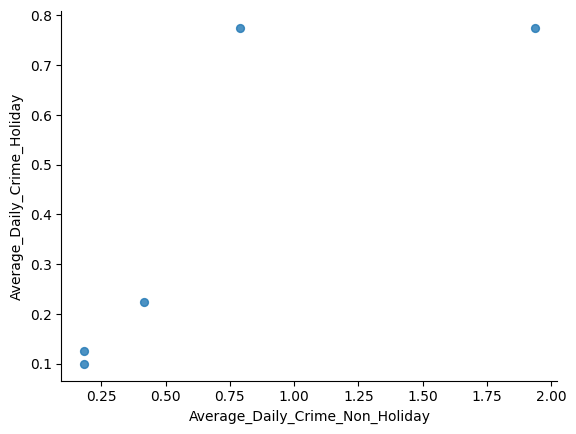

In [ ]:
from matplotlib import pyplot as plt
average_daily_crime_comparison.head(5).plot(kind='scatter', x='Average_Daily_Crime_Non_Holiday', y='Average_Daily_Crime_Holiday', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

The scatter plot you see visualizes the relationship between the average daily crime rate on non-holidays (x-axis) and the average daily crime rate on holidays (y-axis) for each combination of neighbourhood and crime category.

Here's how to interpret it:

* Each point:

Represents a specific crime category within a specific neighbourhood.

* Position of a point:

If a point is close to the diagonal line (if one were drawn from the origin at a 45-degree angle), it suggests that the average daily crime rate for that category in that neighbourhood is similar on both holidays and non-holidays.

If a point is significantly above the diagonal line, it indicates that the average daily crime rate for that category and neighbourhood is higher on holidays than on non-holidays.

If a point is significantly below the diagonal line, it indicates that the average daily crime rate for that category and neighbourhood is lower on holidays than on non-holidays.

* Spread of points:

The overall spread of the points shows the variability in average daily crime rates across different neighborhoods and crime categories, and how this variability differs between holidays and non-holidays.

Looking at the plot, you can visually identify which crime
categories and neighbourhoods tend to have higher or lower daily crime rates during holidays compared to ordinary days. For instance, points clustered below the diagonal suggest crime is generally lower on holidays for those categories and locations.

In [ ]:
display(average_daily_crime_comparison)

,HOOD_158,MCI_CATEGORY,Average_Daily_Crime_Non_Holiday,Average_Daily_Crime_Holiday
0,001,Assault,0.790992,0.775
1,001,Auto Theft,1.935961,0.775
2,001,Break and Enter,0.417312,0.225
3,001,Robbery,0.182970,0.100
4,001,Theft Over,0.184377,0.125
...,...,...,...,...
785,174,Assault,0.298381,0.275
786,174,Auto Theft,0.045039,0.000
787,174,Break and Enter,0.110486,0.075
788,174,Robbery,0.030260,0.000


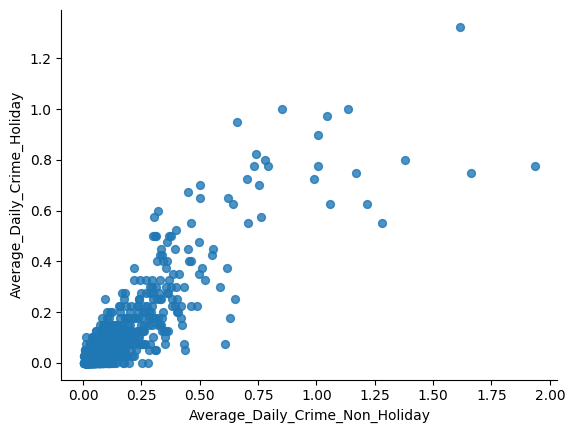

In [ ]:
from matplotlib import pyplot as plt
average_daily_crime_comparison.plot(kind='scatter', x='Average_Daily_Crime_Non_Holiday', y='Average_Daily_Crime_Holiday', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

## **4. Create a column: WEEKEND and anlysis of weekday vs weekends by occurence date**

In [ ]:
# Create a column: WEEKEND, to indicate whether OCC_DATE is a weekend or not. 0 is no and 1 is yes.
df_mci_occ['OCC_DOW'] = df_mci_occ['OCC_DATE'].dt.day_name()
df_mci_occ['WEEKEND'] = df_mci_occ['OCC_DOW'].apply(lambda x: 1 if x in ['Saturday', 'Sunday'] else 0)
df_mci_occ

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y,OCC_MONTH_SEQ,OCC_DAY_SEQ,OCC_WEEK_SEQ,HOLIDAY,WEEKEND
246907,246908,GO-20212356161,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,6,...,Rouge (131),-79.227042,43.834025,-8.819514e+06,5.439793e+06,1,0,1,0,0
246909,246910,GO-202117462,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,5,...,Dovercourt-Wallace Emerson-Junction (93),-79.446454,43.666724,-8.843939e+06,5.414011e+06,1,0,1,0,0
246910,246911,GO-202118202,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,8,...,High Park-Swansea (87),-79.456852,43.655380,-8.845096e+06,5.412265e+06,1,0,1,0,0
246911,246912,GO-202119979,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,13,...,South Riverdale (70),-79.351587,43.660222,-8.833378e+06,5.413010e+06,1,-1,0,0,1
246912,246913,GO-202113220,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,10,...,Keelesdale-Eglinton West (110),-79.471556,43.688058,-8.846733e+06,5.417295e+06,1,-1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430388,430389,GO-2025650600,3/29/2025 4:00:00 AM,2023-09-01 04:00:00,2025,March,29,88,Saturday,2,...,Bay Street Corridor (76),-79.383362,43.662025,-8.836915e+06,5.413288e+06,9,969,139,0,0
430405,430406,GO-20252286226,3/30/2025 4:00:00 AM,2022-11-23 05:00:00,2025,March,30,89,Sunday,16,...,Bay Street Corridor (76),-79.381320,43.651162,-8.836688e+06,5.411616e+06,11,688,99,0,0
430510,430511,GO-2025671642,3/31/2025 4:00:00 AM,2022-01-01 05:00:00,2025,March,31,90,Monday,23,...,Thorncliffe Park (55),-79.346615,43.703234,-8.832825e+06,5.419631e+06,1,362,52,1,1
430516,430517,GO-2025670967,3/31/2025 4:00:00 AM,2023-01-01 05:00:00,2025,March,31,90,Monday,20,...,Milliken (130),-79.272799,43.825655,-8.824608e+06,5.438501e+06,1,727,104,1,1


In [ ]:
# Show rows with column: WEEKEND is 1 only
df_mci_occ[df_mci_occ['WEEKEND'] == 1]

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y,OCC_MONTH_SEQ,OCC_DAY_SEQ,OCC_WEEK_SEQ,HOLIDAY,WEEKEND
246911,246912,GO-202119979,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,13,...,South Riverdale (70),-79.351587,43.660222,-8.833378e+06,5.413010e+06,1,-1,0,0,1
246912,246913,GO-202113220,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,10,...,Keelesdale-Eglinton West (110),-79.471556,43.688058,-8.846733e+06,5.417295e+06,1,-1,0,0,1
246924,246925,GO-202116460,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,4,...,Kennedy Park (124),-79.267046,43.729999,-8.823967e+06,5.423753e+06,1,-1,0,0,1
246928,246929,GO-202116224,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,1,...,Black Creek (24),-79.520359,43.768821,-8.852166e+06,5.429736e+06,1,-1,0,0,1
246929,246930,GO-202116224,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,1,...,Black Creek (24),-79.520359,43.768821,-8.852166e+06,5.429736e+06,1,-1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430185,430186,GO-2025642015,3/28/2025 4:00:00 AM,2023-10-01 04:00:00,2025,March,28,87,Friday,0,...,Palmerston-Little Italy (80),-79.417188,43.663828,-8.840681e+06,5.413565e+06,10,999,143,0,1
430236,430237,GO-2025646101,3/28/2025 4:00:00 AM,2024-06-30 04:00:00,2025,March,28,87,Friday,14,...,Henry Farm (53),-79.344592,43.773571,-8.832600e+06,5.430468e+06,6,1272,182,0,1
430510,430511,GO-2025671642,3/31/2025 4:00:00 AM,2022-01-01 05:00:00,2025,March,31,90,Monday,23,...,Thorncliffe Park (55),-79.346615,43.703234,-8.832825e+06,5.419631e+06,1,362,52,1,1
430516,430517,GO-2025670967,3/31/2025 4:00:00 AM,2023-01-01 05:00:00,2025,March,31,90,Monday,20,...,Milliken (130),-79.272799,43.825655,-8.824608e+06,5.438501e+06,1,727,104,1,1


In [ ]:
# Group by HOOD_158, WEEKEND and MCI_CATEGORY, save results in CSV file for occurence
df_mci_cat_occ['WEEKEND'] = pd.Categorical(df_mci_occ.WEEKEND)
grouped_counts_mci_weekend_categories_with_zeros_occ = df_mci_cat_occ.groupby(['HOOD_158', 'WEEKEND', 'MCI_CATEGORY'], observed=False).count()
grouped_counts_mci_weekend_categories_with_zeros_occ = grouped_counts_mci_weekend_categories_with_zeros_occ.reset_index()
grouped_counts_mci_weekend_categories_with_zeros_occ
grouped_counts_mci_weekend_categories_with_zeros_occ_short = grouped_counts_mci_weekend_categories_with_zeros_occ.filter(['HOOD_158','WEEKEND','MCI_CATEGORY', 'EVENT_UNIQUE_ID'], axis=1)
grouped_counts_mci_weekend_categories_with_zeros_occ_short = grouped_counts_mci_weekend_categories_with_zeros_occ_short.rename(columns={'EVENT_UNIQUE_ID': 'Crime_counts'})
grouped_counts_mci_weekend_categories_with_zeros_occ_short
grouped_counts_mci_weekend_categories_with_zeros_occ_short.to_csv('grouped_counts_mci_weekend_categories_with_zeros_occ_short.csv', index=False)
grouped_counts_mci_weekend_categories_with_zeros_occ_short

,HOOD_158,WEEKEND,MCI_CATEGORY,Crime_counts
0,001,0,Assault,792
1,001,0,Auto Theft,2051
2,001,0,Break and Enter,426
3,001,0,Robbery,184
4,001,0,Theft Over,201
...,...,...,...,...
1575,174,1,Assault,141
1576,174,1,Auto Theft,18
1577,174,1,Break and Enter,41
1578,174,1,Robbery,8


In [ ]:
# sum of crime counts for all HOOD_158 by WEEKEND, MCI_CATEGORY in grouped_counts_mci_weekend_categories_with_zeros_occ_short
sum_crime_counts_weekend_occ = grouped_counts_mci_weekend_categories_with_zeros_occ_short.groupby(['WEEKEND', 'MCI_CATEGORY'], observed=False)['Crime_counts'].sum()
sum_crime_counts_weekend_occ

WEEKEND  MCI_CATEGORY   
0        Assault            61180
         Auto Theft         28617
         Break and Enter    18745
         Robbery             8216
         Theft Over          4582
1        Assault            26624
         Auto Theft          9490
         Break and Enter     7311
         Robbery             3058
         Theft Over          1460
Name: Crime_counts, dtype: int64

In [ ]:
# sum of crime counts for WEEKEND by HOOD_158, MCI_CATEGORY in grouped_counts_mci_weekend_categories_with_zeros_occ_short
sum_crime_counts_weekend_by_hood_158_mci_cat_occ = grouped_counts_mci_weekend_categories_with_zeros_occ_short.groupby(['HOOD_158', 'MCI_CATEGORY', 'WEEKEND'], observed=False)['Crime_counts'].sum()
sum_crime_counts_weekend_by_hood_158_mci_cat_occ

HOOD_158  MCI_CATEGORY     WEEKEND
001       Assault          0           792
                           1           363
          Auto Theft       0          2051
                           1           731
          Break and Enter  0           426
                                      ... 
174       Break and Enter  1            41
          Robbery          0            35
                           1             8
          Theft Over       0            20
                           1             3
Name: Crime_counts, Length: 1580, dtype: int64

In [ ]:
# Calculate the average daily crime count for weekend
# We already have the sum of crime counts grouped by HOOD_158, MCI_CATEGORY, and WEEKEND (0 for weekday)
# The total number of weekend days is stored in the variable weekend_days_count


# Filter the summed crime counts for weekend
weekend_crime_counts = sum_crime_counts_weekend_by_hood_158_mci_cat_occ.loc[(slice(None), slice(None), 1)]

# Calculate weekend days count from 2021 to 2024
weekend_days_count = len(weekend_crime_counts)

# Calculate the average daily crime count for weekend
average_daily_weekend_crime = weekend_crime_counts / weekend_days_count

# Filter the summed crime counts for weekdays(non weekend days)
weekday_crime_counts = sum_crime_counts_weekend_by_hood_158_mci_cat_occ.loc[(slice(None), slice(None), 0)]

# Calculate weekdays count from 2021 to 2024
weekday_days_count = len(weekday_crime_counts)

# Calculate the average daily crime count for weekdays
average_daily_weekday_crime = weekday_crime_counts / weekday_days_count

# Combine the results into a single DataFrame for easier comparison
# Convert the Series to DataFrames and rename the crime count columns
average_daily_weekend_crime_df = average_daily_weekend_crime.reset_index(name='Average_Daily_Crime_Weekend')
average_daily_weekday_crime_df = average_daily_weekday_crime.reset_index(name='Average_Daily_Crime_Weekday')

# Merge the two DataFrames
average_daily_crime_weekend_comparison = average_daily_weekend_crime_df.merge(
    average_daily_weekday_crime_df,
    on=['HOOD_158', 'MCI_CATEGORY'],
    how='outer' # Use outer merge to include combinations with zero counts in either category
)

# Display first 10 of average_daily_crime_comparison
display(average_daily_crime_weekend_comparison.head(5))

,HOOD_158,MCI_CATEGORY,Average_Daily_Crime_Weekend,Average_Daily_Crime_Weekday
0,001,Assault,0.459494,1.002532
1,001,Auto Theft,0.925316,2.596203
2,001,Break and Enter,0.222785,0.539241
3,001,Robbery,0.101266,0.232911
4,001,Theft Over,0.083544,0.254430


In [ ]:
# Merge the two DataFrames(weekend vs holiday)
average_daily_crime_weekend_holiday_comparison = average_daily_weekend_crime_df.merge(
    average_daily_holiday_crime_df,
    on=['HOOD_158', 'MCI_CATEGORY'],
    how='outer' # Use outer merge to include combinations with zero counts in either category
)

# Display first 10 of average_daily_crime_comparison
display(average_daily_crime_weekend_holiday_comparison.head(5))

,HOOD_158,MCI_CATEGORY,Average_Daily_Crime_Weekend,Average_Daily_Crime_Holiday
0,001,Assault,0.459494,0.775
1,001,Auto Theft,0.925316,0.775
2,001,Break and Enter,0.222785,0.225
3,001,Robbery,0.101266,0.100
4,001,Theft Over,0.083544,0.125


## **5. Anlysis of day time vs night time by occurence date**

In [ ]:
# Calculate the average crime count for 11:00 pm - 5:00 am, 5:00 pm - 11:00 pm, 5:00 am - 11:00 am, 11:00 am - 5:00 pm
# We need to group by hour in addition to HOOD_158, WEEKEND, and MCI_CATEGORY

# Group by HOOD_158, WEEKEND, MCI_CATEGORY, and OCC_HOUR to get crime counts by hour
grouped_counts_hourly = df_mci_occ.groupby(['HOOD_158', 'WEEKEND', 'MCI_CATEGORY', 'OCC_HOUR'], observed=False).count().reset_index()

# Filter for the hours between 11:00 pm (23) and 5:00 am (5). Note: This spans across midnight.
# We will consider hours 23, 0, 1, 2, 3, 4
midnight_hours = [23, 0, 1, 2, 3, 4]
midnight_time_crime_counts = grouped_counts_hourly[grouped_counts_hourly['OCC_HOUR'].isin(midnight_hours)]

# Sum the crime counts for night hours
sum_midnight_time_crime_counts = midnight_time_crime_counts.groupby(['HOOD_158', 'WEEKEND', 'MCI_CATEGORY'], observed=False)['OBJECTID'].sum().reset_index(name='Midnight_Time_Crime_Counts')

# Calculate the total number of hours in the night time period
total_midnight_hours = len(midnight_hours)

# To calculate the average hourly crime count, we need the number of unique days in the analysis period.
# We can get this from the OCC_DATE column in the original df_mci_occ
number_of_days = df_mci_occ['OCC_DATE'].dt.date.nunique()

# Calculate the average hourly crime count for the midnight time period
# We divide by the number of days and the number of hours in the midnight time period
average_hourly_midnight_time_crime = sum_midnight_time_crime_counts['Midnight_Time_Crime_Counts'] / (number_of_days * total_midnight_hours)

# Combine the results into a single DataFrame
average_hourly_midnight_time_crime_df = sum_midnight_time_crime_counts[['HOOD_158', 'WEEKEND', 'MCI_CATEGORY']].copy()
average_hourly_midnight_time_crime_df['Average_Hourly_Midnight_Time_Crime'] = average_hourly_midnight_time_crime

# Filter for the hours between 5:00 pm - 11:00 pm (23).
# We will consider hours 17, 18, 19, 20, 21, 22
night_hours = [17, 18, 19, 20, 21, 22]
night_time_crime_counts = grouped_counts_hourly[grouped_counts_hourly['OCC_HOUR'].isin(night_hours)]

# Sum the crime counts for night hours
sum_night_time_crime_counts = night_time_crime_counts.groupby(['HOOD_158', 'WEEKEND', 'MCI_CATEGORY'], observed=False)['OBJECTID'].sum().reset_index(name='Night_Time_Crime_Counts')

# Calculate the total number of hours in the night time period
total_night_hours = len(night_hours)

# Calculate the average hourly crime count for the night time period
# We divide by the number of days and the number of hours in the night time period
average_hourly_night_time_crime = sum_night_time_crime_counts['Night_Time_Crime_Counts'] / (number_of_days * total_night_hours)

# Combine the results into a single DataFrame
average_hourly_night_time_crime_df = sum_night_time_crime_counts[['HOOD_158', 'WEEKEND', 'MCI_CATEGORY']].copy()
average_hourly_night_time_crime_df['Average_Hourly_Night_Time_Crime'] = average_hourly_night_time_crime


# Now let's calculate the crime counts for day time hours (5:00 am - 11:00 am)
# Filter for the hours between 5:00 am - 11:00 am.
# We will consider hours 5, 6, 7, 8, 9, 10
day_hours = [5, 6, 7, 8, 9, 10]
day_time_crime_counts = grouped_counts_hourly[grouped_counts_hourly['OCC_HOUR'].isin(day_hours)]

# Sum the crime counts for day hours
sum_day_time_crime_counts = day_time_crime_counts.groupby(['HOOD_158', 'WEEKEND', 'MCI_CATEGORY'], observed=False)['OBJECTID'].sum().reset_index(name='Day_Time_Crime_Counts')

# Calculate the total number of hours in the day time period
total_day_hours = len(day_hours)

# Calculate the average hourly crime count for the day time period
average_hourly_day_time_crime = sum_day_time_crime_counts['Day_Time_Crime_Counts'] / (number_of_days * total_day_hours)

# Combine the results into a single DataFrame
average_hourly_day_time_crime_df = sum_day_time_crime_counts[['HOOD_158', 'WEEKEND', 'MCI_CATEGORY']].copy()
average_hourly_day_time_crime_df['Average_Hourly_Day_Time_Crime'] = average_hourly_day_time_crime

# Now let's calculate the crime counts for day time hours (11:00 am - 5:00 pm)
# Filter for the hours between 11:00 am - 5:00 pm.
# We will consider hours 11, 12, 1, 2, 3, 4
afternoon_hours = [11, 12, 1, 2, 3, 4]
afternoon_hours_crime_counts = grouped_counts_hourly[grouped_counts_hourly['OCC_HOUR'].isin(afternoon_hours)]

# Sum the crime counts for afternoon hours
sum_afternoon_hours_crime_counts = afternoon_hours_crime_counts.groupby(['HOOD_158', 'WEEKEND', 'MCI_CATEGORY'], observed=False)['OBJECTID'].sum().reset_index(name='Afternoon_Hours_Crime_Counts')

# Calculate the total number of hours in the afternoon time period
total_afternoon_hours = len(afternoon_hours)

# Calculate the average hourly crime count for the afternoon time period
average_hourly_afternoon_hours_crime = sum_afternoon_hours_crime_counts['Afternoon_Hours_Crime_Counts'] / (number_of_days * total_afternoon_hours)

# Combine the results into a single DataFrame
average_hourly_afternoon_hours_crime_df = sum_afternoon_hours_crime_counts[['HOOD_158', 'WEEKEND', 'MCI_CATEGORY']].copy()
average_hourly_afternoon_hours_crime_df['Average_Hourly_Afternoon_Hours_Crime'] = average_hourly_afternoon_hours_crime

# Merge the three DataFrames for comparison
average_hourly_time_comparison = average_hourly_midnight_time_crime_df.merge(
    average_hourly_night_time_crime_df,
    on=['HOOD_158', 'WEEKEND', 'MCI_CATEGORY'],
    how='outer' # Use outer merge to include combinations with zero counts in either category
)

average_hourly_time_comparison = average_hourly_time_comparison.merge(
    average_hourly_day_time_crime_df,
    on=['HOOD_158', 'WEEKEND', 'MCI_CATEGORY'],
    how='outer')

average_hourly_time_comparison = average_hourly_time_comparison.merge(
    average_hourly_afternoon_hours_crime_df,
    on=['HOOD_158', 'WEEKEND', 'MCI_CATEGORY'],
    how='outer')

# Display the comparison DataFrame
display(average_hourly_time_comparison.head())

,HOOD_158,WEEKEND,MCI_CATEGORY,Average_Hourly_Midnight_Time_Crime,Average_Hourly_Night_Time_Crime,Average_Hourly_Day_Time_Crime,Average_Hourly_Afternoon_Hours_Crime
0,001,0,Assault,0.016769,0.027721,0.013461,0.019507
1,001,0,Auto Theft,0.056924,0.091148,0.038102,0.048026
2,001,0,Break and Enter,0.025781,0.006274,0.010609,0.021903
3,001,0,Robbery,0.003993,0.006731,0.003765,0.006160
4,001,0,Theft Over,0.006046,0.006616,0.004563,0.006046


# **6. Anlysis of PREMISES_TYPE by occurence date**

In [ ]:
# crime rate by PREMISES_TYPE by occurence date
df_mci_cat_occ['PREMISES_TYPE'] = pd.Categorical(df_mci_cat_occ.PREMISES_TYPE)
df_mci_cat_occ['PREMISES_TYPE'].unique()


['Other', 'Commercial', 'Outside', 'House', 'Apartment', 'Transit', 'Educational']
Categories (7, object): ['Apartment', 'Commercial', 'Educational', 'House', 'Other', 'Outside',
                         'Transit']

In [ ]:
# Group by HOOD_158, HOLIDAY and PREMISES_TYPE, save results in CSV file for occurence
df_mci_cat_occ['PREMISES_TYPE'] = pd.Categorical(df_mci_occ.PREMISES_TYPE)
grouped_counts_mci_premises_type_holiday_categories_with_zeros_occ = df_mci_cat_occ.groupby(['HOOD_158', 'HOLIDAY', 'MCI_CATEGORY', 'PREMISES_TYPE'], observed=False).count()
grouped_counts_mci_premises_type_holiday_categories_with_zeros_occ = grouped_counts_mci_premises_type_holiday_categories_with_zeros_occ.reset_index()
grouped_counts_mci_premises_type_holiday_categories_with_zeros_occ
grouped_counts_mci_premises_type_holiday_categories_with_zeros_occ_short = grouped_counts_mci_premises_type_holiday_categories_with_zeros_occ.filter(['HOOD_158','HOLIDAY','MCI_CATEGORY', 'PREMISES_TYPE', 'EVENT_UNIQUE_ID'], axis=1)
grouped_counts_mci_premises_type_holiday_categories_with_zeros_occ_short = grouped_counts_mci_premises_type_holiday_categories_with_zeros_occ_short.rename(columns={'EVENT_UNIQUE_ID': 'Crime_counts'})
grouped_counts_mci_premises_type_holiday_categories_with_zeros_occ_short
grouped_counts_mci_premises_type_holiday_categories_with_zeros_occ_short.to_csv('grouped_counts_mci_premises_type_holiday_categories_with_zeros_occ_short.csv', index=False)
grouped_counts_mci_premises_type_holiday_categories_with_zeros_occ_short


,HOOD_158,HOLIDAY,MCI_CATEGORY,PREMISES_TYPE,Crime_counts
0,001,0,Assault,Apartment,214
1,001,0,Assault,Commercial,300
2,001,0,Assault,Educational,58
3,001,0,Assault,House,237
4,001,0,Assault,Other,86
...,...,...,...,...,...
11055,174,1,Theft Over,Educational,0
11056,174,1,Theft Over,House,0
11057,174,1,Theft Over,Other,0
11058,174,1,Theft Over,Outside,0


# **7. Anlysis of LOCATION_TYPE by occurence date**

In [ ]:
# crime rate by LOCATION_TYPE by occurence date
df_mci_cat_occ['LOCATION_TYPE'] = pd.Categorical(df_mci_occ.LOCATION_TYPE)
df_mci_cat_occ['LOCATION_TYPE'].unique()

['Unknown', 'Other Commercial / Corporate Places (For Prof..., 'Streets, Roads, Highways (Bicycle Path, Priva..., 'Convenience Stores', 'Single Home, House (Attach Garage, Cottage, M..., ..., 'Ttc Subway Tunnel / Outdoor Tracks', 'Halfway House / Young Offender Group Home', 'Other Passenger Train', 'Cargo Train', 'Ttc Support Vehicle']
Length: 54
Categories (54, object): ['Apartment (Rooming House, Condo)', 'Bank And Other Financial Institutions (Money ...,
                          'Bar / Restaurant', 'Cargo Train', ..., 'Ttc Support Vehicle',
                          'Ttc Wheel Trans Vehicle', 'Universities / Colleges', 'Unknown']

In [ ]:
# Group by HOOD_158, HOLIDAY and PREMISES_TYPE, save results in CSV file for occurence
grouped_counts_mci_premises_type_location_holiday_categories_with_zeros_occ = df_mci_cat_occ.groupby(['HOOD_158', 'HOLIDAY', 'MCI_CATEGORY', 'PREMISES_TYPE', 'LOCATION_TYPE'], observed=False).count()
grouped_counts_mci_premises_type_location_holiday_categories_with_zeros_occ = grouped_counts_mci_premises_type_location_holiday_categories_with_zeros_occ.reset_index()
grouped_counts_mci_premises_type_location_holiday_categories_with_zeros_occ
grouped_counts_mci_premises_type_location_holiday_categories_with_zeros_occ_short = grouped_counts_mci_premises_type_location_holiday_categories_with_zeros_occ.filter(['HOOD_158','HOLIDAY','MCI_CATEGORY', 'PREMISES_TYPE', 'LOCATION_TYPE', 'EVENT_UNIQUE_ID'], axis=1)
grouped_counts_mci_premises_type_location_holiday_categories_with_zeros_occ_short = grouped_counts_mci_premises_type_location_holiday_categories_with_zeros_occ_short.rename(columns={'EVENT_UNIQUE_ID': 'Crime_counts'})
grouped_counts_mci_premises_type_location_holiday_categories_with_zeros_occ_short
grouped_counts_mci_premises_type_location_holiday_categories_with_zeros_occ_short.to_csv('grouped_counts_mci_premises_type_location_holiday_categories_with_zeros_occ_short.csv', index=False)
grouped_counts_mci_premises_type_location_holiday_categories_with_zeros_occ_short

,HOOD_158,HOLIDAY,MCI_CATEGORY,PREMISES_TYPE,LOCATION_TYPE,Crime_counts
0,001,0,Assault,Apartment,"Apartment (Rooming House, Condo)",214
1,001,0,Assault,Apartment,Bank And Other Financial Institutions (Money M...,0
2,001,0,Assault,Apartment,Bar / Restaurant,0
3,001,0,Assault,Apartment,Cargo Train,0
4,001,0,Assault,Apartment,"Commercial Dwelling Unit (Hotel, Motel, B & B,...",0
...,...,...,...,...,...,...
597235,174,1,Theft Over,Transit,Ttc Subway Tunnel / Outdoor Tracks,0
597236,174,1,Theft Over,Transit,Ttc Support Vehicle,0
597237,174,1,Theft Over,Transit,Ttc Wheel Trans Vehicle,0
597238,174,1,Theft Over,Transit,Universities / Colleges,0


# **8. Anlysis of OFFENCE by occurence date**


In [ ]:
# crime rate by OFFENCE by occurence date
df_mci_cat_occ['OFFENCE'] = pd.Categorical(df_mci_cat_occ.OFFENCE)
df_mci_cat_occ['OFFENCE'].unique()

['Theft Of Motor Vehicle', 'B&E', 'Theft From Motor Vehicle Over', 'Assault', 'Assault With Weapon', ..., 'Theft Of Utilities Over', 'Set/Place Trap/Intend Death/Bh', 'Hoax Terrorism Causing Bodily', 'B&E - To Steal Firearm', 'Unlawfully Causing Bodily Harm']
Length: 50
Categories (50, object): ['Administering Noxious Thing', 'Aggravated Aslt Peace Officer', 'Aggravated Assault',
                          'Aggravated Assault Avails Pros', ..., 'Traps Likely Cause Bodily Harm',
                          'Unlawfully Causing Bodily Harm', 'Unlawfully In Dwelling-House',
                          'Use Firearm / Immit Commit Off']

In [ ]:
# Group by HOOD_158, HOLIDAY, PREMISES_TYPE, LOCATION AND DEFENCE save results in CSV file for occurence
grouped_counts_mci_premises_type_location_offence_holiday_categories_with_zeros_occ = df_mci_cat_occ.groupby(['HOOD_158', 'HOLIDAY', 'PREMISES_TYPE', 'OFFENCE'], observed=False).count()
grouped_counts_mci_premises_type_location_offence_holiday_categories_with_zeros_occ = grouped_counts_mci_premises_type_location_offence_holiday_categories_with_zeros_occ.reset_index()
grouped_counts_mci_premises_type_location_offence_holiday_categories_with_zeros_occ
grouped_counts_mci_premises_type_location_offence_holiday_categories_with_zeros_occ_short = grouped_counts_mci_premises_type_location_offence_holiday_categories_with_zeros_occ.filter(['HOOD_158','HOLIDAY', 'PREMISES_TYPE', 'OFFENCE', 'EVENT_UNIQUE_ID'], axis=1)
grouped_counts_mci_premises_type_location_offence_holiday_categories_with_zeros_occ_short = grouped_counts_mci_premises_type_location_offence_holiday_categories_with_zeros_occ_short.rename(columns={'EVENT_UNIQUE_ID': 'Crime_counts'})
grouped_counts_mci_premises_type_location_offence_holiday_categories_with_zeros_occ_short
grouped_counts_mci_premises_type_location_offence_holiday_categories_with_zeros_occ_short.to_csv('grouped_counts_mci_premises_type_location_offence_holiday_categories_with_zeros_occ_short.csv', index=False)
grouped_counts_mci_premises_type_location_offence_holiday_categories_with_zeros_occ_short

,HOOD_158,HOLIDAY,PREMISES_TYPE,OFFENCE,Crime_counts
0,001,0,Apartment,Administering Noxious Thing,0
1,001,0,Apartment,Aggravated Aslt Peace Officer,0
2,001,0,Apartment,Aggravated Assault,2
3,001,0,Apartment,Aggravated Assault Avails Pros,0
4,001,0,Apartment,Air Gun Or Pistol: Bodily Harm,0
...,...,...,...,...,...
110595,174,1,Transit,Theft Over - Shoplifting,0
110596,174,1,Transit,Traps Likely Cause Bodily Harm,0
110597,174,1,Transit,Unlawfully Causing Bodily Harm,0
110598,174,1,Transit,Unlawfully In Dwelling-House,0


## **9. Analysis by report date-Crime Count by Neighbourhood**

 Let's create a visual representation of all the crimes by neighbourhood to see what the data looks in the current form.

 - A bar chart to show just the count by neighbourhood.

 - I replaced the `HOOD_158` value with the actual name of the neihbourhood from `NEIGHBOURHOOD_158`


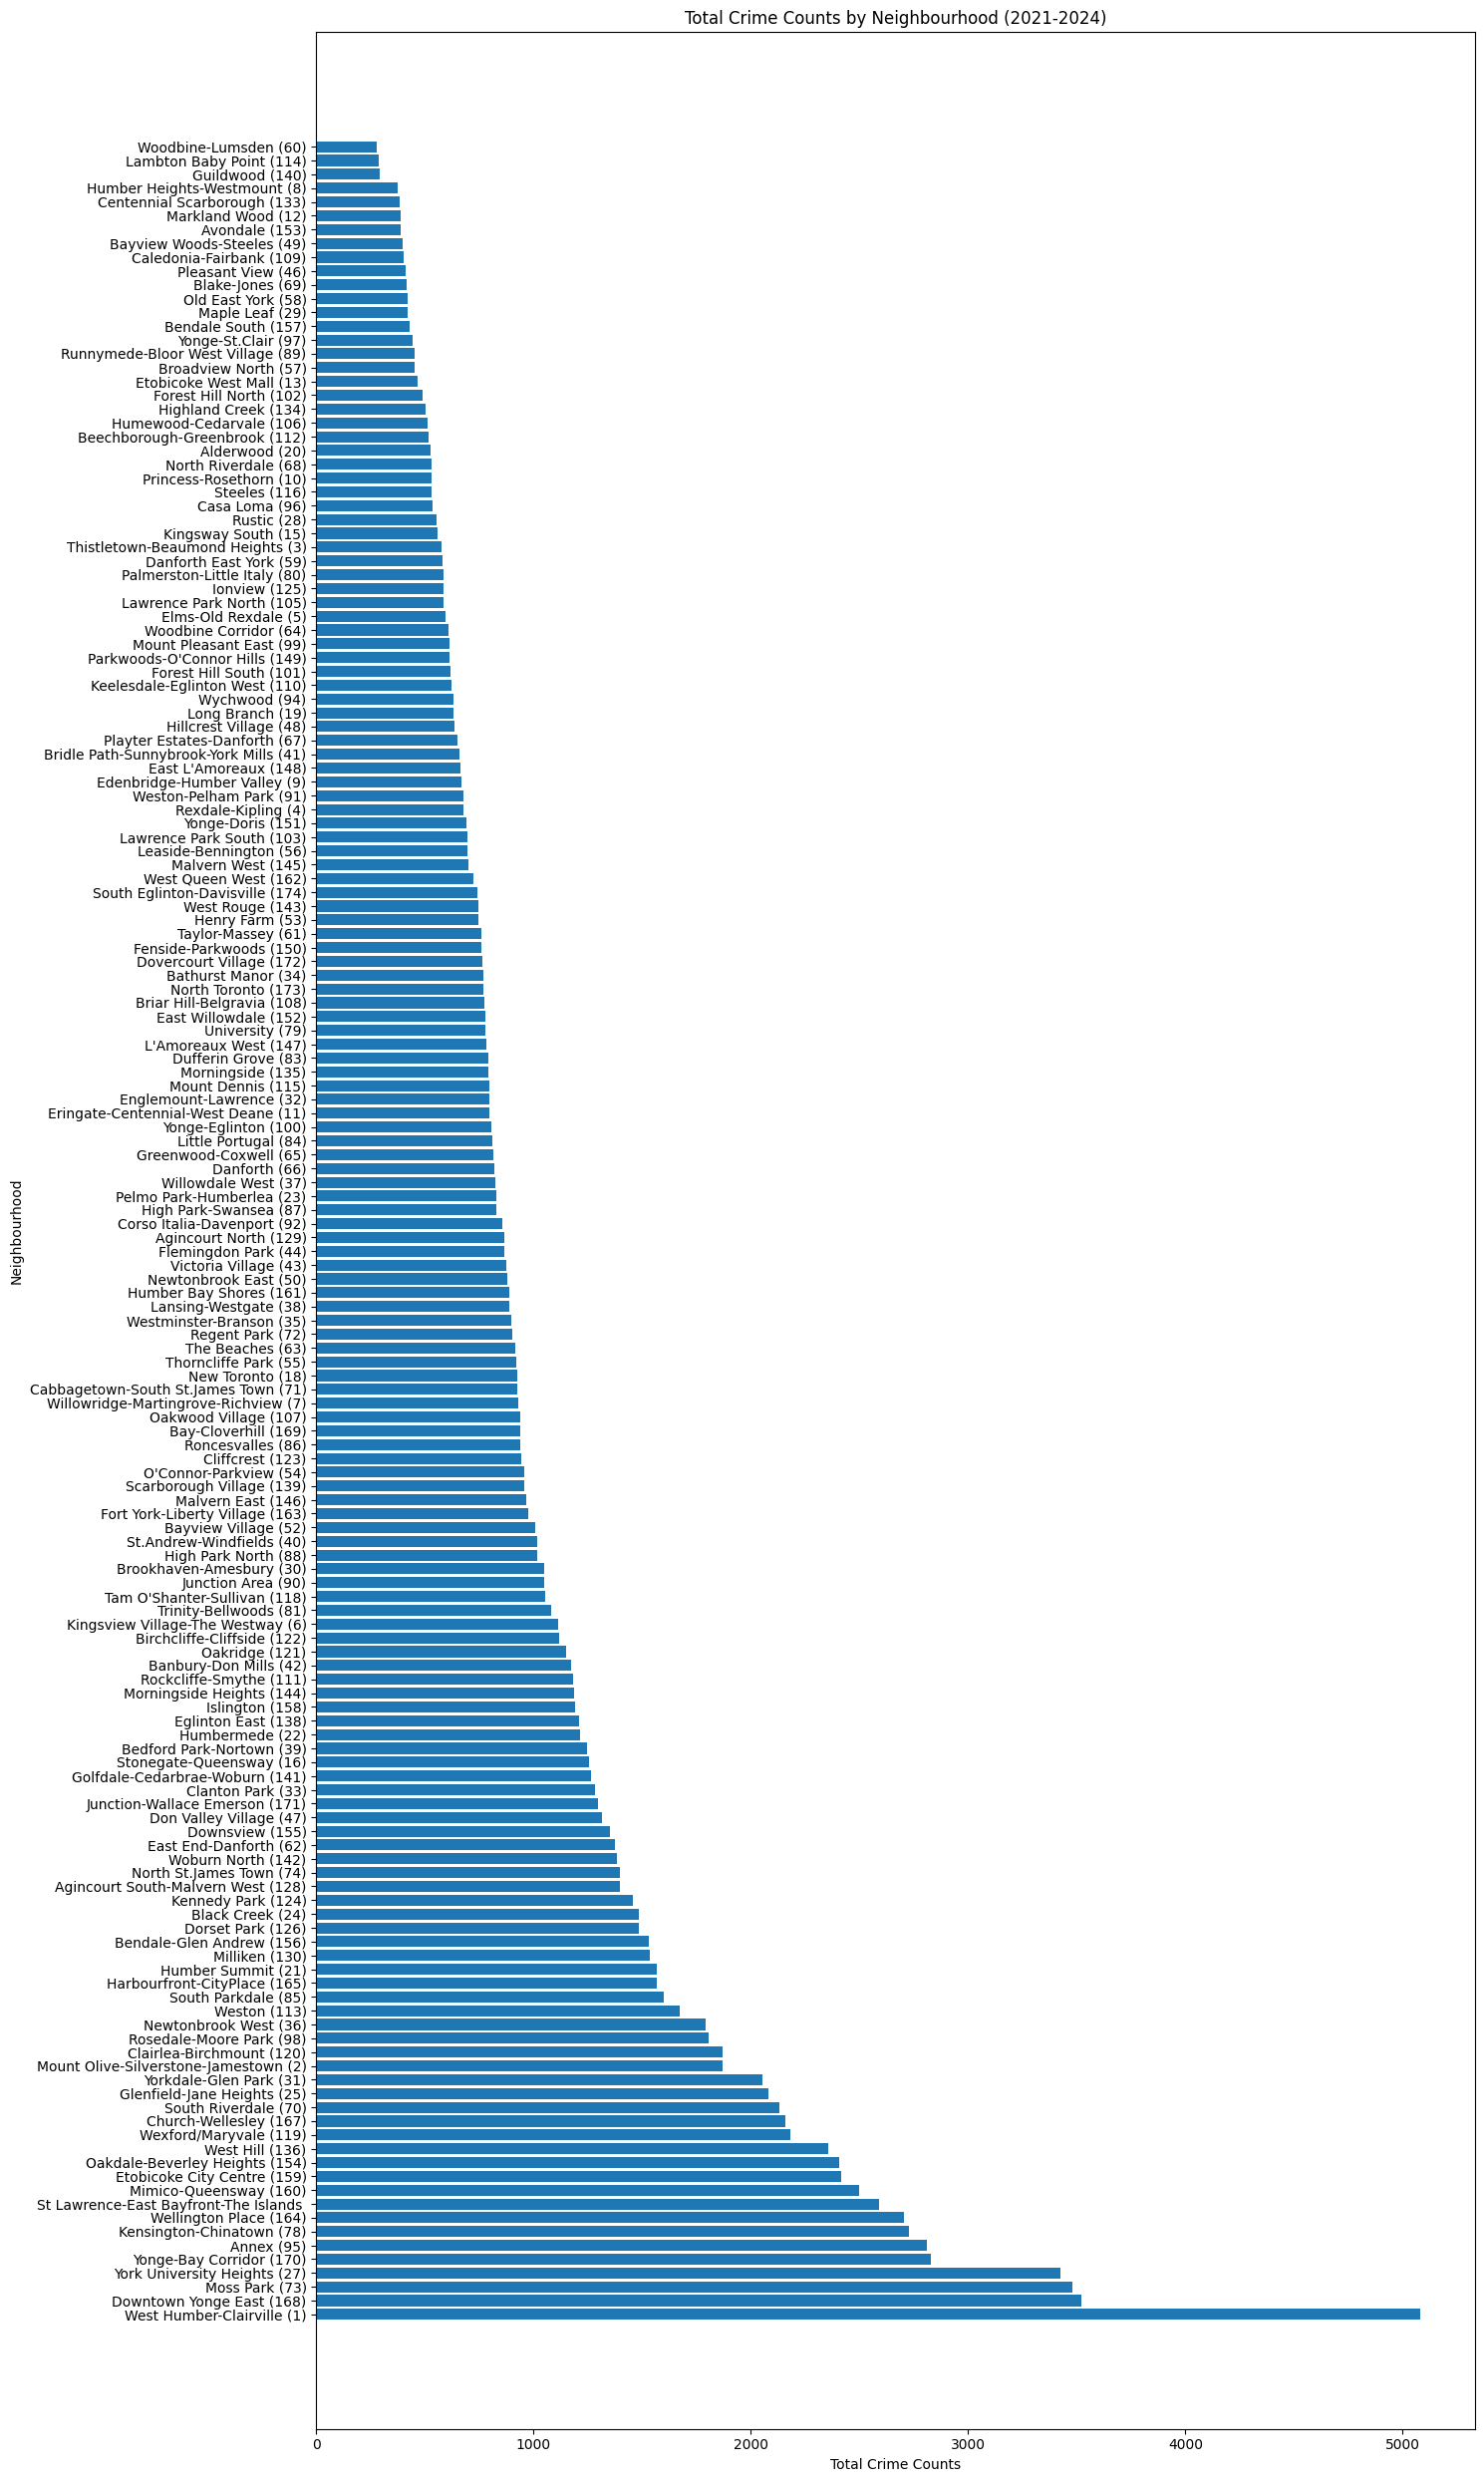

In [ ]:
# generate a bar graph with HOOD_158 in X axis and Crime_counts as y.

import matplotlib.pyplot as plt

# Group by HOOD_158 and sum Crime_counts
hood_crime_counts = grouped_counts_all_crimes_with_zeros_short.groupby('HOOD_158', observed=False)['Crime_counts'].sum().reset_index()

# Merge with original dataframe to get NEIGHBOURHOOD_158
hood_crime_counts = hood_crime_counts.merge(df_mci[['HOOD_158', 'NEIGHBOURHOOD_158']].drop_duplicates(), on='HOOD_158')

# Sort by Crime_counts in descending order and take the top N (optional)
hood_crime_counts = hood_crime_counts.sort_values(by='Crime_counts', ascending=False) # set this to `True`, to switch order

# Create the bar plot
plt.figure(figsize=(15, 25))
plt.barh(hood_crime_counts['NEIGHBOURHOOD_158'], hood_crime_counts['Crime_counts'])
plt.ylabel('Neighbourhood')
plt.xlabel('Total Crime Counts')
plt.title('Total Crime Counts by Neighbourhood (2021-2024)')
plt.tight_layout()
plt.show()

**As you can see above, this shows that a single neighbourhood heavily outweights all the other neigbourhoods in terms of crime count.**

### What does it mean?

The bar chart provides a visual summary of the total crime counts for each neighbourhood over the period from 2021 to 2024. The length of each bar directly represents the total number of crimes reported in that specific neighbourhood. The fact that "West Humber-Clairville (1)" has the longest bar indicates that it has the highest cumulative number of crime incidents during this period compared to all other neighbourhoods.

In [ ]:
grouped_counts_all_crimes_with_zeros_short.Crime_counts.describe()

,Crime_counts
count,32864.000000
mean,5.201010
std,4.617836
min,0.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,48.000000


**Lets describe what each of these values mean:**


*   `count`: there are a total of `32,864` entries, which is 52 Weeks x 4 Years x 158 neighbourhoods entries. That gives us a count of crimes per each neighbourhood, per week.
*   `mean`: avg number of crimes per each neighbourhood, per week is `~5.2`
*   `std`: std deviation number of crimes per each neighbourhood, per week is `~4.62`. Which means there is a moderate amount variation in weekly crime count.
*   `min`: there are some neighbourhood weeks with `0` crime counts
*   `25%`: 25% of the neighbourhood-weeks had `2` or fewer crimes
*   `50%`: 50% of the neighbourhood-weeks had `4` or fewer crimes
*   `75%`: 75% of the neighbourhood-weeks had `7` or fewer crimes
*   `max`: The largest amount of crimes commited in a single neighbourhood in a single week is `48`.




In [ ]:
# Find the maximum crime count
max_crime_count = grouped_counts_all_crimes_with_zeros_short['Crime_counts'].max()

# Filter the DataFrame to show rows with the maximum crime count
rows_with_max_crime = grouped_counts_all_crimes_with_zeros_short[grouped_counts_all_crimes_with_zeros_short['Crime_counts'] == max_crime_count]

# Display the row(s)
display(rows_with_max_crime)


# Get the HOOD_158 and WEEK_SEQ for the row with the maximum crime count
hood_with_max_crime = rows_with_max_crime['HOOD_158'].iloc[0]
week_with_max_crime = rows_with_max_crime['WEEK_SEQ'].iloc[0]

# Filter the original df_mci DataFrame to show rows that match the neighbourhood and week
detailed_max_crime_data = df_mci[(df_mci['HOOD_158'] == hood_with_max_crime) &
                                 (df_mci['WEEK_SEQ'] == week_with_max_crime)]

# Display the filtered data
display(detailed_max_crime_data)
detailed_max_crime_data['MCI_CATEGORY'].unique()


,HOOD_158,WEEK_SEQ,Crime_counts
127,001,128,48


,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y,REPORT_MONTH_SEQ,DAY_SEQ,WEEK_SEQ
344712,344713,GO-20231346933,6/12/2023 4:00:00 AM,5/30/2023 4:00:00 AM,2023,June,12,163,Monday,17,...,West Humber-Clairville (1),001,West Humber-Clairville (1),-79.592844,43.680811,-8.860235e+06,5.416179e+06,6,889,128
344713,344714,GO-20231346692,6/12/2023 4:00:00 AM,6/5/2023 4:00:00 AM,2023,June,12,163,Monday,17,...,West Humber-Clairville (1),001,West Humber-Clairville (1),-79.575623,43.701944,-8.858318e+06,5.419433e+06,6,889,128
344714,344715,GO-20231342056,6/12/2023 4:00:00 AM,6/10/2023 4:00:00 AM,2023,June,12,163,Monday,8,...,West Humber-Clairville (1),001,West Humber-Clairville (1),-79.565505,43.709148,-8.857192e+06,5.420542e+06,6,889,128
344749,344750,GO-20231342056,6/12/2023 4:00:00 AM,6/10/2023 4:00:00 AM,2023,June,12,163,Monday,8,...,West Humber-Clairville (1),001,West Humber-Clairville (1),-79.565505,43.709148,-8.857192e+06,5.420542e+06,6,889,128
344758,344759,GO-20231347016,6/12/2023 4:00:00 AM,3/2/2023 5:00:00 AM,2023,June,12,163,Monday,17,...,West Humber-Clairville (1),001,West Humber-Clairville (1),-79.607455,43.743646,-8.861861e+06,5.425856e+06,6,889,128
344759,344760,GO-20231342388,6/12/2023 4:00:00 AM,6/12/2023 4:00:00 AM,2023,June,12,163,Monday,8,...,West Humber-Clairville (1),001,West Humber-Clairville (1),-79.597219,43.733205,-8.860722e+06,5.424247e+06,6,889,128
344780,344781,GO-20231342683,6/12/2023 4:00:00 AM,6/12/2023 4:00:00 AM,2023,June,12,163,Monday,9,...,West Humber-Clairville (1),001,West Humber-Clairville (1),-79.595509,43.686688,-8.860532e+06,5.417084e+06,6,889,128
344781,344782,GO-20231342824,6/12/2023 4:00:00 AM,6/11/2023 4:00:00 AM,2023,June,12,163,Monday,9,...,West Humber-Clairville (1),001,West Humber-Clairville (1),-79.599400,43.730879,-8.860965e+06,5.423889e+06,6,889,128
344782,344783,GO-20231342619,6/12/2023 4:00:00 AM,6/12/2023 4:00:00 AM,2023,June,12,163,Monday,9,...,West Humber-Clairville (1),001,West Humber-Clairville (1),-79.595571,43.686823,-8.860538e+06,5.417105e+06,6,889,128
344826,344827,GO-20231340525,6/12/2023 4:00:00 AM,6/12/2023 4:00:00 AM,2023,June,12,163,Monday,0,...,West Humber-Clairville (1),001,West Humber-Clairville (1),-79.569255,43.700495,-8.857609e+06,5.419209e+06,6,889,128


array(['Auto Theft', 'Break and Enter', 'Assault', 'Robbery'],
      dtype=object)

 > * I have taken the neighbourhood-week with the highest crime count and created a detailed view of that neighbourhood in that week (June 12th, 2023 - June 18th, 2023).
 * The point of interest is that, out of the five types of crime categories, all but one was committed.
 * The only type of crime excluded was `Theft Over` which refers to  *any theft over the value of $5000 (CAD)*.
 >
 > * **Why is this interesting?** When comparing this with the neighbourhood profiles, it would be interesting to see where in the avg. household income this neigbourhood will be.
 >* As per this data it suggests that `West Humber-Clairville (1)` would be in the lower end. (at least for the year 2023)

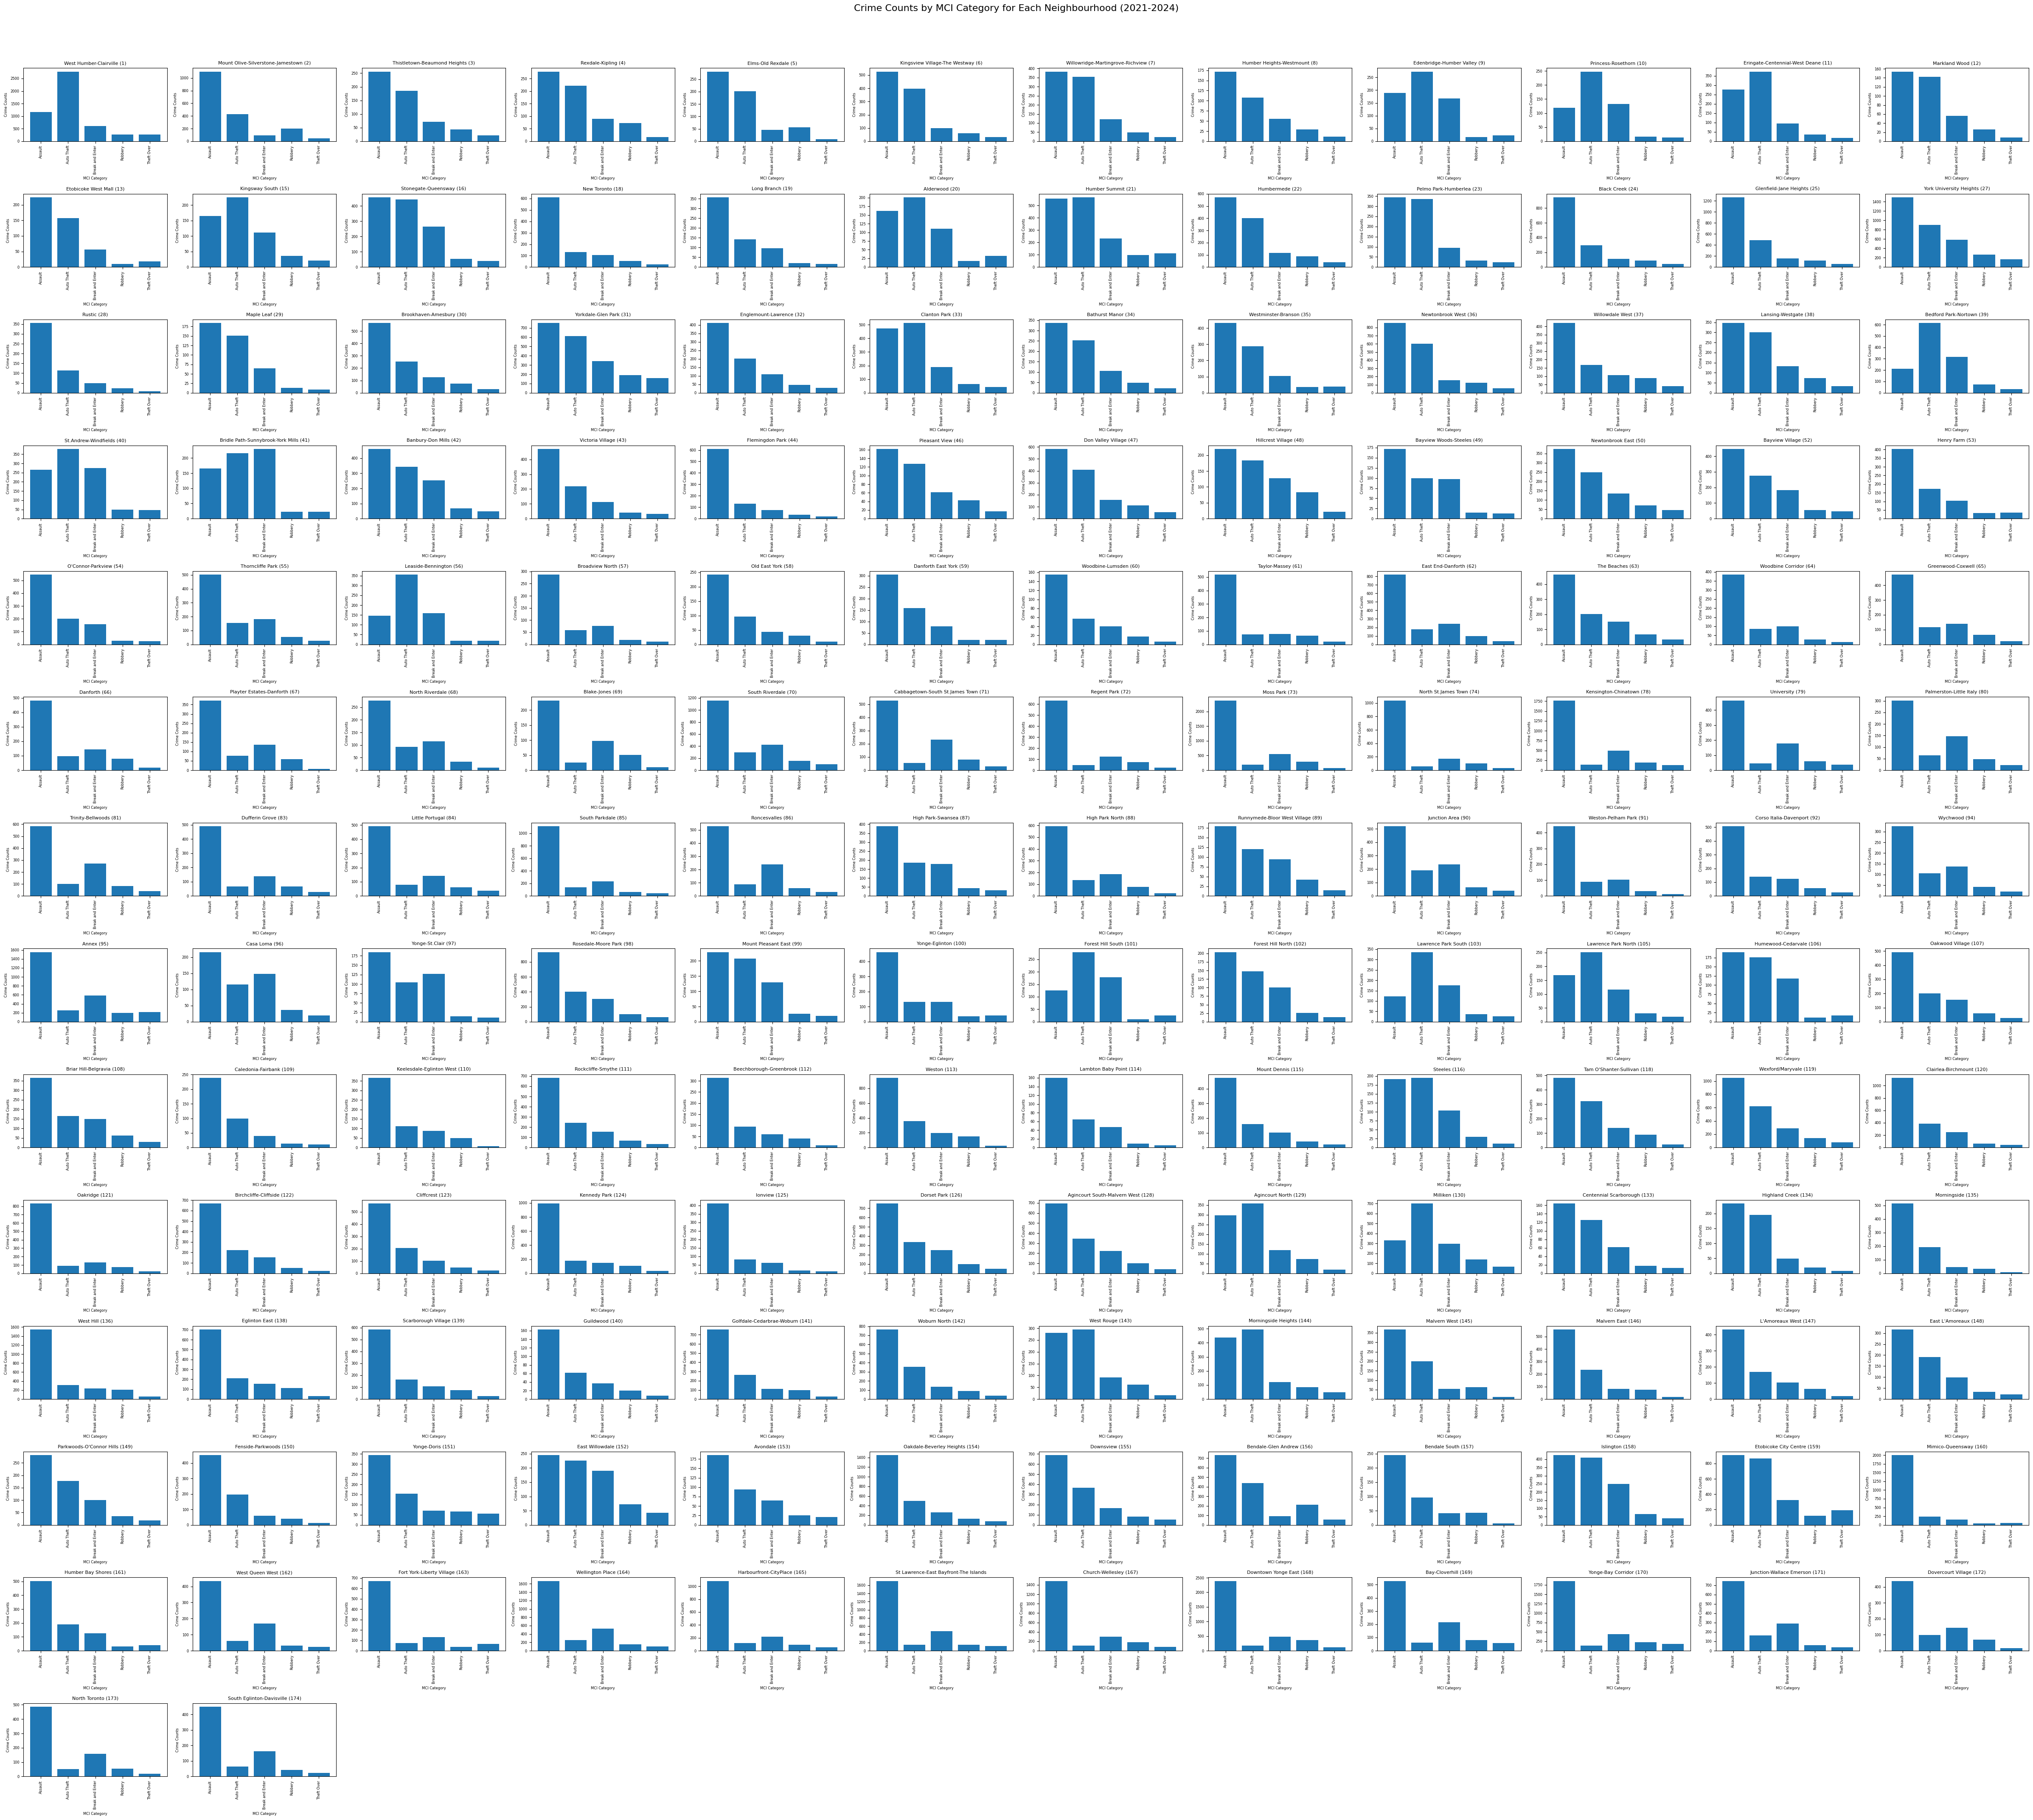

In [ ]:
import matplotlib.pyplot as plt
# Group by HOOD_158 and MCI_CATEGORY and sum Crime_counts
hood_mci_crime_counts = grouped_counts_mci_categories_with_zeros_short.groupby(['HOOD_158', 'MCI_CATEGORY'], observed=False)['Crime_counts'].sum().reset_index()

# Get unique HOOD_158 values
unique_hoods = hood_mci_crime_counts['HOOD_158'].unique()

# Determine the number of rows and columns for the grid
num_hoods = len(unique_hoods)
cols = 12
rows = (num_hoods + cols - 1) // cols

# Create the figure and axes for the grid
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Add a main title to the figure
fig.suptitle('Crime Counts by MCI Category for Each Neighbourhood (2021-2024)', fontsize=16, y=1.02) # Add suptitle here

# Merge with original dataframe to get NEIGHBOURHOOD_158 names
hood_names = df_mci[['HOOD_158', 'NEIGHBOURHOOD_158']].drop_duplicates()

# Iterate through each unique hood and generate a bar graph
for i, hood in enumerate(unique_hoods):
  ax = axes[i]
  hood_data = hood_mci_crime_counts[hood_mci_crime_counts['HOOD_158'] == hood]

  # Get the corresponding neighbourhood name
  neighbourhood_name = hood_names[hood_names['HOOD_158'] == hood]['NEIGHBOURHOOD_158'].iloc[0]

  ax.bar(hood_data['MCI_CATEGORY'], hood_data['Crime_counts'])
  ax.set_title(f'{neighbourhood_name}', fontsize=8) # Set the title to the neighbourhood name and reduce font size
  ax.set_xlabel('MCI Category', fontsize=6) # Reduce font size
  ax.set_ylabel('Crime Counts', fontsize=6) # Reduce font size
  ax.tick_params(axis='x', rotation=90, labelsize=6) # Rotate and reduce font size for x-axis labels
  ax.tick_params(axis='y', labelsize=6) # Reduce font size for y-axis labels


# Hide any unused subplots
for j in range(i + 1, len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



> **This confirms two assumptions:**
> 1.   The data needs to be normalized, as some neighbourhood's high crime count skew the others that aren't as high. This disparity makes direct comparisons of crime risk difficult without considering factors like population. Normalizing or standardizing the data (e.g., calculating crime rate per capita) would be a crucial next step for a fair comparison.
>
> 2.   The most common type of crime committed seems to be `Assault`. Let's prove this quantatively below.







In [ ]:
# Calculate the total count for each MCI_CATEGORY across all neighbourhoods
total_counts = grouped_counts_mci_categories_with_zeros_short.groupby('MCI_CATEGORY', observed=False)['Crime_counts'].sum()

# Sort them to see which category has the highest overall number of incidents.
total_counts.sort_values(ascending=False)

# Display the sorted counts based on the MCI Category
print(total_counts)


MCI_CATEGORY
Assault            89397
Auto Theft         38113
Break and Enter    26079
Robbery            11266
Theft Over          6071
Name: Crime_counts, dtype: int64


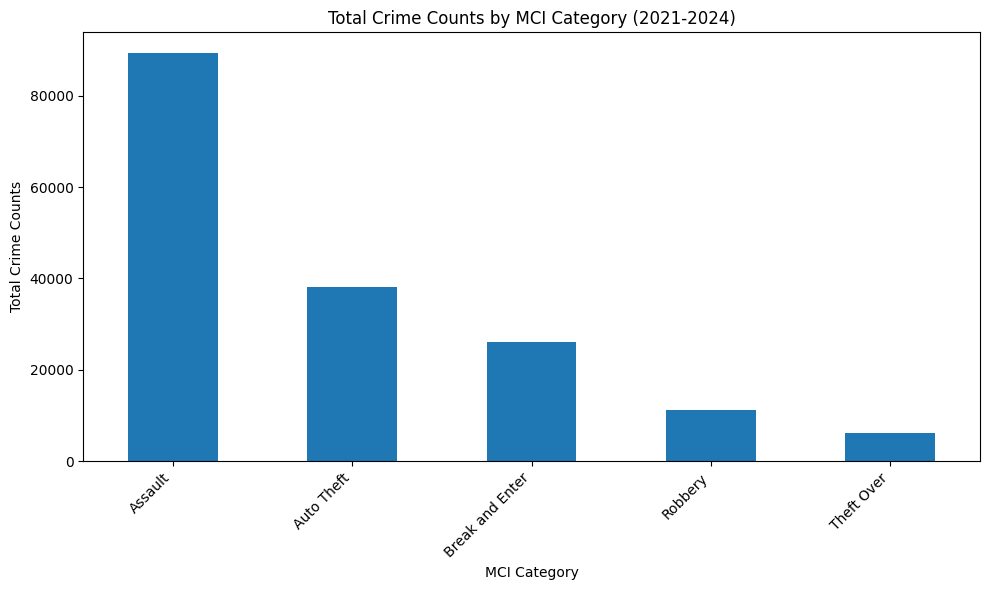

In [ ]:
import matplotlib.pyplot as plt

# Sort the total counts in descending order for better visualization
sorted_total_counts = total_counts.sort_values(ascending=False)

# Create a bar chart
plt.figure(figsize=(10, 6))
sorted_total_counts.plot(kind='bar')

plt.title('Total Crime Counts by MCI Category (2021-2024)')
plt.xlabel('MCI Category')
plt.ylabel('Total Crime Counts')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()



> As seen above, `Assault` far outweights any other type of crime. We will need to fix this with normalization.



## **10. Pilot analysis by joint Major Crime Indicator with neibourhood profile**

In [403]:
# Lets import the neighbourhood-profiles-2021-158-model data
df_neighbourhood_profiles = pd.read_excel('neighbourhood-profiles-2021-158-model(1).xlsx')

# what is the shape of the data frame
df_neighbourhood_profiles.shape

(2603, 159)

In [404]:
df_neighbourhood_profiles.head(10)

,Neighbourhood Name,West Humber-Clairville,Mount Olive-Silverstone-Jamestown,Thistletown-Beaumond Heights,Rexdale-Kipling,Elms-Old Rexdale,Kingsview Village-The Westway,Willowridge-Martingrove-Richview,Humber Heights-Westmount,Edenbridge-Humber Valley,...,Harbourfront-CityPlace,St Lawrence-East Bayfront-The Islands,Church-Wellesley,Downtown Yonge East,Bay-Cloverhill,Yonge-Bay Corridor,Junction-Wallace Emerson,Dovercourt Village,North Toronto,South Eglinton-Davisville
0,Neighbourhood Number,1,2,3,4,5,6,7,8,9,...,165,166,167,168,169,170,171,172,173,174
1,TSNS 2020 Designation,Not an NIA or Emerging Neighbourhood,Neighbourhood Improvement Area,Neighbourhood Improvement Area,Not an NIA or Emerging Neighbourhood,Neighbourhood Improvement Area,Neighbourhood Improvement Area,Not an NIA or Emerging Neighbourhood,Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,...,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood
2,Total - Age groups of the population - 25% sam...,33300,31345,9850,10375,9355,22005,22445,10005,15190,...,28135,31285,22320,17700,16670,12645,23180,12380,15885,22735
3,0 to 14 years,4295,5690,1495,1575,1610,3915,3500,1370,2070,...,2065,2285,895,1055,745,970,3075,1365,1315,2190
4,0 to 4 years,1460,1650,505,505,440,1245,1065,395,520,...,1030,1045,495,480,370,500,1135,445,535,910
5,5 to 9 years,1345,1860,540,615,480,1325,1190,430,740,...,655,690,230,325,255,270,1020,430,390,670
6,10 to 14 years,1485,2175,455,455,685,1350,1240,540,815,...,385,550,175,245,120,200,925,490,390,610
7,15 to 64 years,23640,21490,6615,6950,6355,14385,13865,6245,9650,...,24540,25015,19315,14695,13815,10820,17200,9040,12780,17495
8,15 to 19 years,1860,2280,570,515,635,1245,1175,525,885,...,365,600,465,390,535,340,750,460,465,575
9,20 to 24 years,3175,2675,745,715,685,1605,1330,580,780,...,2250,1990,3010,2340,3810,1825,1185,640,960,1115


In [405]:
#Copy the transpose logic
# We want to tranpose the table such that the first column values become the header
df_neighbourhood_profiles = df_neighbourhood_profiles.transpose()

# Set the first row as the new header
new_header = df_neighbourhood_profiles.iloc[0]
df_neighbourhood_profiles = df_neighbourhood_profiles[1:]
df_neighbourhood_profiles.columns = new_header

# Display the first few rows with the correct headers
display(df_neighbourhood_profiles.head())

Neighbourhood Name,Neighbourhood Number,TSNS 2020 Designation,Total - Age groups of the population - 25% sample data,0 to 14 years,0 to 4 years,5 to 9 years,10 to 14 years,15 to 64 years,15 to 19 years,20 to 24 years,...,Between 9 a.m. and 11:59 a.m.,Between 12 p.m. and 4:59 a.m.,Total - Eligibility for instruction in the minority official language for the population in private households born in 2003 or later - 25% sample data,Children eligible for instruction in the minority official language,Children not eligible for instruction in the minority official language,"Total - Eligibility and instruction in the minority official language, for the population in private households born between 2003 and 2015 (inclusive) - 25% sample data",Children eligible for instruction in the minority official language,Eligible children who have been instructed in the minority official language at the primary or secondary level in Canada,Eligible children who have not been instructed in the minority official language at the primary or secondary level in Canada,Children not eligible for instruction in the minority official language
West Humber-Clairville,1,Not an NIA or Emerging Neighbourhood,33300,4295,1460,1345,1485,23640,1860,3175,...,1665,2935,5430,410,5020,3875,335,255,75,3540
Mount Olive-Silverstone-Jamestown,2,Neighbourhood Improvement Area,31345,5690,1650,1860,2175,21490,2280,2675,...,1145,2965,7285,510,6780,5540,395,245,145,5145
Thistletown-Beaumond Heights,3,Neighbourhood Improvement Area,9850,1495,505,540,455,6615,570,745,...,395,635,1860,180,1685,1325,120,75,45,1205
Rexdale-Kipling,4,Not an NIA or Emerging Neighbourhood,10375,1575,505,615,455,6950,515,715,...,425,775,1910,135,1770,1370,90,75,25,1275
Elms-Old Rexdale,5,Neighbourhood Improvement Area,9355,1610,440,480,685,6355,635,685,...,355,675,2015,95,1920,1520,70,60,10,1445


In [406]:
#Rename columns with duplicate names
cols=pd.Series(df_neighbourhood_profiles.columns)
for dup in df_neighbourhood_profiles.columns[df_neighbourhood_profiles.columns.duplicated(keep=False)]:
    cols[df_neighbourhood_profiles.columns.get_loc(dup)] = ([dup + '.' + str(d_idx)
                                     if d_idx != 0
                                     else dup
                                     for d_idx in range(df_neighbourhood_profiles.columns.get_loc(dup).sum())]
                                    )
df_neighbourhood_profiles.columns=cols
dfnp_selection = df_neighbourhood_profiles[['Total - Age groups of the population - 25% sample data']]
dfnp_selection = dfnp_selection.rename(columns={'Total - Age groups of the population - 25% sample data': 'POP_TOTAL'})
dfnp_selection['Neighbourhood_Number'] = df_neighbourhood_profiles[['Neighbourhood Number']]
dfnp_selection['POP_AGE_GROUP_0_14'] = df_neighbourhood_profiles[['  0 to 14 years.1']]
dfnp_selection['POP_AGE_GROUP_15_64'] = df_neighbourhood_profiles[['  15 to 64 years.1']]
dfnp_selection['POP_AGE_GROUP_65_'] = df_neighbourhood_profiles[['  65 years and over.1']]
dfnp_selection['POP_AVG_AGE'] = df_neighbourhood_profiles[['Average age of the population']]
dfnp_selection['POP_MED_AGE'] = df_neighbourhood_profiles[['Median age of the population']]
dfnp_selection['MARRIED_%'] = df_neighbourhood_profiles['  Married or living common-law'] / df_neighbourhood_profiles['Total - Marital status for the total population aged 15 years and over - 25% sample data']
dfnp_selection['POP_GOV_SUPP_SHARE'] = df_neighbourhood_profiles[['  Government transfers (%)']]
dfnp_selection['AVG_HHOLD_SIZE'] = df_neighbourhood_profiles[['Average household size']]
dfnp_selection['AVG_TOT_HHOLD_INC'] = df_neighbourhood_profiles[['  Average total income of household in 2020 ($)']]
dfnp_selection['OWNER_HHOLDS_%'] = df_neighbourhood_profiles['  Owner'] / df_neighbourhood_profiles['Total - Private households by tenure - 25% sample data']
dfnp_selection['DW_W_CONDO_STATUS_%'] = df_neighbourhood_profiles['  Condominium'] / df_neighbourhood_profiles['Total - Occupied private dwellings by condominium status - 25% sample data']
dfnp_selection['HHOLDS_UNSUIT_HOU_%'] = df_neighbourhood_profiles['  Not suitable'] / df_neighbourhood_profiles['Total - Private households by housing suitability - 25% sample data']
dfnp_selection['DW_REQ_MAJ_REPAIR_%'] = df_neighbourhood_profiles['  Major repairs needed'] / df_neighbourhood_profiles['Total - Occupied private dwellings by dwelling condition - 25% sample data']
dfnp_selection['SCTI_RAT_GT30_%'] = df_neighbourhood_profiles['  Spending 30% or more of income on shelter costs'] / df_neighbourhood_profiles['Total - Owner and tenant households with household total income greater than zero, in non-farm, non-reserve private dwellings by shelter-cost-to-income ratio - 25% sample data']
dfnp_selection['HHOLD_OWN_MRTG_HOLD_%'] = df_neighbourhood_profiles[['  % of owner households with a mortgage']]
dfnp_selection['HHOLD_OWN_SCTI_GT30_%'] = df_neighbourhood_profiles[['  % of owner households spending 30% or more of its income on shelter costs']]
dfnp_selection['AVG_DW_VAL'] = df_neighbourhood_profiles[['  Average value of dwellings ($)']]
dfnp_selection['HHOLDS_IN_SUBS_HOUS_%'] = df_neighbourhood_profiles[['  % of tenant households in subsidized housing']] / 100
dfnp_selection['HHOLDS_OWN_AVG_MNTH_COST'] = df_neighbourhood_profiles[['  Average monthly shelter costs for owned dwellings ($)']]
dfnp_selection['HHOLDS_RENT_AVG_MNTH_COST'] = df_neighbourhood_profiles[['  Average monthly shelter costs for rented dwellings ($)']]
dfnp_selection['AVG_FAM_SIZE'] = df_neighbourhood_profiles[['Average size of census families']]
dfnp_selection['ONE_PAR_FAM_%'] = df_neighbourhood_profiles['  Total one-parent families'] / df_neighbourhood_profiles['Total number of census families in private households - 25% sample data']
dfnp_selection['AVG_NUM_CH_PER_FAM'] = df_neighbourhood_profiles[['Average number of children in census families with children']]
dfnp_selection['HHOLD_FIRST_LANG_EN_%'] = df_neighbourhood_profiles['  English'] / df_neighbourhood_profiles['Total - First official language spoken for the population in private households - 25% sample data']
dfnp_selection['HHOLD_FIRST_LANG_FR_%'] = df_neighbourhood_profiles['  French'] / df_neighbourhood_profiles['Total - First official language spoken for the population in private households - 25% sample data']
dfnp_selection['HHOLD_FIRST_LANG_ENFR_%'] = df_neighbourhood_profiles['  English and French'] / df_neighbourhood_profiles['Total - First official language spoken for the population in private households - 25% sample data']
dfnp_selection['HHOLD_FIRST_LANG_OTH_%'] = df_neighbourhood_profiles['  Neither English nor French'] / df_neighbourhood_profiles['Total - First official language spoken for the population in private households - 25% sample data']
dfnp_selection['POP_NONCITIZ_%'] = df_neighbourhood_profiles['  Not Canadian citizens'] / df_neighbourhood_profiles['Total - Citizenship for the population in private households - 25% sample data']
dfnp_selection['POP_NON_IMMIGR_%'] = df_neighbourhood_profiles['  Non-immigrants'] / df_neighbourhood_profiles['Total - Immigrant status and period of immigration for the population in private households - 25% sample data']
dfnp_selection['POP_IMMIGR_%'] = df_neighbourhood_profiles['  Immigrants'] / df_neighbourhood_profiles['Total - Immigrant status and period of immigration for the population in private households - 25% sample data']
dfnp_selection['POP_TEMP_RES_%'] = df_neighbourhood_profiles['  Non-permanent residents'] / df_neighbourhood_profiles['Total - Immigrant status and period of immigration for the population in private households - 25% sample data']
dfnp_selection['PARTICIP_RATE'] = df_neighbourhood_profiles[['Participation rate']]
dfnp_selection['UNEMPLOY_RATE'] = df_neighbourhood_profiles[['Unemployment rate']]
dfnp_selection['POP_NO_EDUC_%'] = df_neighbourhood_profiles['  No certificate, diploma or degree.1'] / df_neighbourhood_profiles['Total - Highest certificate, diploma or degree for the population aged 25 to 64 years in private households - 25% sample data']
dfnp_selection['POP_HIGH_SCH_EDUC_%'] = df_neighbourhood_profiles['  High (secondary) school diploma or equivalency certificate.1'] / df_neighbourhood_profiles['Total - Highest certificate, diploma or degree for the population aged 25 to 64 years in private households - 25% sample data']
dfnp_selection['POP_POSTSEC_EDUC_%'] = df_neighbourhood_profiles['  Postsecondary certificate, diploma or degree.1'] / df_neighbourhood_profiles['Total - Highest certificate, diploma or degree for the population aged 25 to 64 years in private households - 25% sample data']
dfnp_selection['COMMUTE_CAR_%'] = df_neighbourhood_profiles['  Car, truck or van'] / df_neighbourhood_profiles['Total - Main mode of commuting for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_TRANSIT_%'] = df_neighbourhood_profiles['  Public transit'] / df_neighbourhood_profiles['Total - Main mode of commuting for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_WALK_%'] = df_neighbourhood_profiles['  Walked'] / df_neighbourhood_profiles['Total - Main mode of commuting for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_CYCLE_%'] = df_neighbourhood_profiles['  Bicycle'] / df_neighbourhood_profiles['Total - Main mode of commuting for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_OTHER_%'] = df_neighbourhood_profiles['  Other method'] / df_neighbourhood_profiles['Total - Main mode of commuting for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_LT_30_MIN_%'] = (df_neighbourhood_profiles['  Less than 15 minutes'] + df_neighbourhood_profiles['  15 to 29 minutes']) / df_neighbourhood_profiles['Total - Commuting duration for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_30_59_MIN_%'] = (df_neighbourhood_profiles['  30 to 44 minutes'] + df_neighbourhood_profiles['  45 to 59 minutes']) / df_neighbourhood_profiles['Total - Commuting duration for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_GT_59_MIN_%'] = df_neighbourhood_profiles['  60 minutes and over'] / df_neighbourhood_profiles['Total - Commuting duration for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_START_5_6_AM_%'] = df_neighbourhood_profiles['  Between 5 a.m. and 5:59 a.m.'] / df_neighbourhood_profiles['Total - Time leaving for work for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_START_6_7_AM_%'] = df_neighbourhood_profiles['  Between 6 a.m. and 6:59 a.m.'] / df_neighbourhood_profiles['Total - Time leaving for work for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_START_7_8_AM_%'] = df_neighbourhood_profiles['  Between 7 a.m. and 7:59 a.m.'] / df_neighbourhood_profiles['Total - Time leaving for work for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_START_8_9_AM_%'] = df_neighbourhood_profiles['  Between 8 a.m. and 8:59 a.m.'] / df_neighbourhood_profiles['Total - Time leaving for work for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_START_9_AM_noon_%'] = df_neighbourhood_profiles['  Between 9 a.m. and 11:59 a.m.'] / df_neighbourhood_profiles['Total - Time leaving for work for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_START_noon_5_AM_%'] = df_neighbourhood_profiles['  Between 12 p.m. and 4:59 a.m.'] / df_neighbourhood_profiles['Total - Time leaving for work for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection.head(5)

scalingColumns = ['POP_AGE_GROUP_0_14','POP_AGE_GROUP_15_64','POP_AGE_GROUP_65_','POP_AVG_AGE','POP_MED_AGE','MARRIED_%','AVG_HHOLD_SIZE','AVG_TOT_HHOLD_INC',
                  'AVG_DW_VAL','HHOLDS_OWN_AVG_MNTH_COST','HHOLDS_RENT_AVG_MNTH_COST','AVG_FAM_SIZE','AVG_NUM_CH_PER_FAM'];

import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define different scalers
minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

# Create a ColumnTransformer to apply different scalers to different columns
# You can customize this based on which scaling method you want for each column
# For example, you could have specific columns scaled with StandardScaler, others with MinMaxScaler, etc.
# Here, I'm demonstrating how to apply a different scaler to each column for illustration.
# In a real scenario, you would likely choose one or two scaling methods and apply them to groups of columns.

# Example: Applying different scalers to a few columns
# For simplicity and demonstration, I'll apply a different scaler to the first 3 columns
# and then apply StandardScaler to the rest of the scalingColumns.
# You should adjust this based on your specific requirements.

transformers = [
    #('minmax', minmax_scaler, scalingColumns)
    ('standard', standard_scaler, scalingColumns)
    #('robust', robust_scaler, scalingColumns)
    #('standard_rest', standard_scaler, scalingColumns)
]

preprocessor = ColumnTransformer(transformers=transformers, remainder='passthrough')

# Create a pipeline that first applies the preprocessor and then does nothing further (for demonstration)
# In a real application, you would typically add a model after the preprocessor.
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Fit and transform the selected columns
dfnp_scaled = pipeline.fit_transform(dfnp_selection[scalingColumns])

# To see the result as a DataFrame (optional)
# Get the column names after transformation
# The order of columns in the transformed array will be based on the order in the transformers list
# and then the 'remainder' columns (which we set to 'passthrough', but there are none in this case as we selected specific columns)
# You might need to adjust this if you have 'remainder' columns.
transformed_column_names = [t[0] for t in preprocessor.transformers_ if t[2] is not None]
# Since we are transforming all columns in scalingColumns, the transformed columns will correspond to these names
transformed_dfnp_selection = pd.DataFrame(dfnp_scaled, columns=scalingColumns)

display(transformed_dfnp_selection.head())


import pandas as pd
# Keep the non-scaled columns
dfnp_non_scaled = dfnp_selection[['Neighbourhood_Number']]

# Reset the index of the transformed DataFrame to align with the original
transformed_dfnp_selection.reset_index(drop=True, inplace=True)
dfnp_non_scaled.reset_index(drop=True, inplace=True)

# Concatenate the non-scaled columns with the scaled columns
df_final = pd.concat([dfnp_non_scaled, transformed_dfnp_selection], axis=1)

# Display the first few rows of the final DataFrame
display(df_final.head())


,POP_AGE_GROUP_0_14,POP_AGE_GROUP_15_64,POP_AGE_GROUP_65_,POP_AVG_AGE,POP_MED_AGE,MARRIED_%,AVG_HHOLD_SIZE,AVG_TOT_HHOLD_INC,AVG_DW_VAL,HHOLDS_OWN_AVG_MNTH_COST,HHOLDS_RENT_AVG_MNTH_COST,AVG_FAM_SIZE,AVG_NUM_CH_PER_FAM
0,-0.321216,0.291588,-0.139260,-0.312234,-0.623757,-0.318403,1.533931,-0.347566,-0.623559,-0.839122,-0.500952,0.566975,0.753743
1,1.222908,-0.113283,-0.762201,-1.348804,-1.116033,-0.754443,1.773182,-0.653889,-0.918392,-0.873405,-0.729563,1.924277,2.114789
2,0.348876,-0.349457,0.216706,-0.120277,-0.328392,-0.266271,1.294681,-0.401131,-0.362141,-0.790147,-0.898013,1.019409,1.434266
3,0.348876,-0.383197,0.238954,0.225246,0.360795,-0.695084,0.337677,-0.590281,-0.552799,-1.128077,-0.973214,0.566975,0.753743
4,0.931564,-0.231370,-0.406235,-0.657758,-0.525302,-1.298294,1.055430,-0.513282,-0.841735,-0.951766,-0.645338,1.019409,1.434266


,Neighbourhood_Number,POP_AGE_GROUP_0_14,POP_AGE_GROUP_15_64,POP_AGE_GROUP_65_,POP_AVG_AGE,POP_MED_AGE,MARRIED_%,AVG_HHOLD_SIZE,AVG_TOT_HHOLD_INC,AVG_DW_VAL,HHOLDS_OWN_AVG_MNTH_COST,HHOLDS_RENT_AVG_MNTH_COST,AVG_FAM_SIZE,AVG_NUM_CH_PER_FAM
0,1,-0.321216,0.291588,-0.139260,-0.312234,-0.623757,-0.318403,1.533931,-0.347566,-0.623559,-0.839122,-0.500952,0.566975,0.753743
1,2,1.222908,-0.113283,-0.762201,-1.348804,-1.116033,-0.754443,1.773182,-0.653889,-0.918392,-0.873405,-0.729563,1.924277,2.114789
2,3,0.348876,-0.349457,0.216706,-0.120277,-0.328392,-0.266271,1.294681,-0.401131,-0.362141,-0.790147,-0.898013,1.019409,1.434266
3,4,0.348876,-0.383197,0.238954,0.225246,0.360795,-0.695084,0.337677,-0.590281,-0.552799,-1.128077,-0.973214,0.566975,0.753743
4,5,0.931564,-0.231370,-0.406235,-0.657758,-0.525302,-1.298294,1.055430,-0.513282,-0.841735,-0.951766,-0.645338,1.019409,1.434266


In [407]:
df_neighbourhood_profiles.shape

(158, 2603)

In [408]:
# Check for null values in each column and sum them
null_counts = df_neighbourhood_profiles.isnull().sum()

# Display the columns with their null counts
print(null_counts[null_counts > 0])

Series([], dtype: int64)


In [409]:
# Select the Neighbourhood Number and Total Population columns
df_population = df_neighbourhood_profiles[['Neighbourhood Number', 'Total - Age groups of the population - 25% sample data']].copy()

# Rename the population column for clarity
df_population = df_population.rename(columns={'Total - Age groups of the population - 25% sample data': 'Population_2021'})

# Display the first few rows of the new DataFrame
display(df_population.head())

Neighbourhood Name,Neighbourhood Number,Population_2021
West Humber-Clairville,1,33300
Mount Olive-Silverstone-Jamestown,2,31345
Thistletown-Beaumond Heights,3,9850
Rexdale-Kipling,4,10375
Elms-Old Rexdale,5,9355


In [410]:
# Convert 'Neighbourhood Number' to string and pad with leading zeros to match 'HOOD_158' format
df_population['Neighbourhood Number'] = df_population['Neighbourhood Number'].astype(str).str.zfill(3)

# Now attempt the merge again with the corrected 'Neighbourhood Number' format
df_crime_population = grouped_counts_all_crimes_with_zeros_short.merge(
    df_population,
    left_on='HOOD_158',  # Column in grouped_counts_all_crimes_with_zeros_short
    right_on='Neighbourhood Number',  # Column in df_population
    how='inner' # Use an inner merge to keep only matching neighbourhoods
)

# Drop the redundant 'Neighbourhood Number' column after merging
df_crime_population = df_crime_population.drop('Neighbourhood Number', axis=1)

# Display the first few rows and shape of the merged DataFrame
display(df_crime_population.head())
print(df_crime_population.shape)

,HOOD_158,WEEK_SEQ,Crime_counts,Population_2021
0,001,1,19,33300
1,001,2,11,33300
2,001,3,12,33300
3,001,4,20,33300
4,001,5,12,33300


(32864, 4)


In [411]:
# Calculate the crime rate per 1,000 people
df_crime_population['Crime_Rate_Per_1000'] = (df_crime_population['Crime_counts'] / df_crime_population['Population_2021']) * 1000

# Display the first few rows with the new crime rate column
display(df_crime_population.head())

,HOOD_158,WEEK_SEQ,Crime_counts,Population_2021,Crime_Rate_Per_1000
0,001,1,19,33300,0.570571
1,001,2,11,33300,0.33033
2,001,3,12,33300,0.36036
3,001,4,20,33300,0.600601
4,001,5,12,33300,0.36036


In [420]:
import pandas as pd
import numpy as np
from scipy.stats import variation
from scipy.fft import fft, fftfreq

# 1) Load & rename
crime_df = grouped_counts_mci_categories_with_zeros_occ_short.rename(columns={'Crime_counts':'Count'})

# 2) Merge population & cast to numeric
df_population['Population_2021'] = (
    pd.to_numeric(df_population['Population_2021'], errors='coerce')
    .fillna(0)
    .astype(float)
)
crime_df = (
    crime_df
    .merge(df_population[['Neighbourhood Number','Population_2021']],
           left_on='HOOD_158', right_on='Neighbourhood Number', how='left')
    .drop('Neighbourhood Number', axis=1)
)

# 3) Ensure numeric & fill
for col in ['Count','Population_2021']:
    crime_df[col] = (
        pd.to_numeric(crime_df[col], errors='coerce')
        .fillna(0)
        .astype(float)
    )

# 4) Compute per‑capita rate
crime_df['Crime_Rate_Per_1000'] = (
    (crime_df['Count'] / crime_df['Population_2021']) * 1000
).fillna(0).astype(float)

# 5) Build full grid and fill
all_hoods      = crime_df['HOOD_158'].unique()
all_weeks      = crime_df['OCC_WEEK_SEQ'].unique()
all_categories = crime_df['MCI_CATEGORY'].unique()

full_idx = pd.MultiIndex.from_product(
    [all_hoods, all_weeks, all_categories],
    names=['HOOD_158','OCC_WEEK_SEQ','MCI_CATEGORY']
)
panel = (
    full_idx
    .to_frame(index=False)
    .merge(crime_df, on=['HOOD_158','OCC_WEEK_SEQ','MCI_CATEGORY'], how='left')
)

panel['Count'] = panel['Count'].fillna(0).astype(float)
panel['Population_2021'] = (
    panel
    .groupby('HOOD_158', observed=True)['Population_2021']
    .transform(lambda x: x.fillna(x.mean()))
    .fillna(0)
    .astype(float)
)
panel['Crime_Rate_Per_1000'] = (
    (panel['Count'] / panel['Population_2021']) * 1000
).fillna(0).astype(float)

# 6) Map real date → quarter
week_map = (
    df_mci_occ[['OCC_WEEK_SEQ','OCC_DATE']]
    .drop_duplicates()
    .assign(OCC_DATE=lambda df: pd.to_datetime(df['OCC_DATE']))
)
week_map['OCC_YEAR']    = week_map['OCC_DATE'].dt.year
week_map['OCC_QUARTER'] = week_map['OCC_DATE'].dt.quarter

panel = panel.merge(week_map, on='OCC_WEEK_SEQ', how='left')

# 7) Seasonality: mean rate by true calendar quarter
seasonality = (
    panel
    .groupby(['HOOD_158','MCI_CATEGORY','OCC_YEAR','OCC_QUARTER'], observed=True)['Crime_Rate_Per_1000']
    .mean()
    .unstack(['OCC_QUARTER','OCC_YEAR'])
)
seasonality.columns = [
    f"mean_rate_Q{q}_{y}"
    for q,y in seasonality.columns
]
seasonality = seasonality.reset_index()

# 8) Volatility: CV on counts & rates
volatility = (
    panel
    .groupby(['HOOD_158','MCI_CATEGORY'], observed=True)
    .agg(
        cv_counts = ('Count', lambda x: variation(x) if x.mean()!=0 else np.nan),
        cv_rates  = ('Crime_Rate_Per_1000', lambda x: variation(x) if x.mean()!=0 else np.nan),
    )
    .reset_index()
)

# 9) Trend: YoY % change on annual average rate
annual_rates = (
    panel
    .groupby(['HOOD_158','MCI_CATEGORY','OCC_YEAR'], observed=True)['Crime_Rate_Per_1000']
    .mean()
    .unstack('OCC_YEAR')
)
for prev, nxt in zip(annual_rates.columns[:-1], annual_rates.columns[1:]):
    annual_rates[f"YoY_Rate_Change_{prev}_vs_{nxt}"] = (
        (annual_rates[nxt] - annual_rates[prev]) / annual_rates[prev] * 100
    )
trend = annual_rates.filter(like="YoY_Rate_Change").reset_index()

# 10) Concentration: HHI on rates
concentration = (
    panel
    .groupby(['HOOD_158','MCI_CATEGORY'], observed=True)['Crime_Rate_Per_1000']
    .apply(lambda x: np.sum((x/x.sum())**2) if x.sum()>0 else 0)
    .rename('hhi_rate_concentration')
    .reset_index()
)

# 11) Merge all temporal features
temp_feats = (
    seasonality
    .merge(volatility,    on=['HOOD_158','MCI_CATEGORY'])
    .merge(trend,         on=['HOOD_158','MCI_CATEGORY'])
    .merge(concentration, on=['HOOD_158','MCI_CATEGORY'])
)

# 12) Fourier features with peak month
weekly_totals = panel.groupby(['HOOD_158','OCC_WEEK_SEQ'], observed=True)['Crime_Rate_Per_1000'].sum().reset_index()
fourier_list = []
for hood, grp in weekly_totals.groupby('HOOD_158', observed=True):
    rates = grp.sort_values('OCC_WEEK_SEQ')['Crime_Rate_Per_1000'].values
    N     = len(rates)
    yf    = fft(rates)
    xf    = fftfreq(N)
    feats = {'HOOD_158': hood}
    for label, freq in [('yearly',1/52), ('half',1/26)]:
        idx = np.argmin(np.abs(xf - freq))
        if 0 < idx < N/2:
            amp   = np.abs(yf[idx]) * 2 / N
            phase = np.angle(yf[idx]) % (2*np.pi)
            months = 12 if label=='yearly' else 6
            feats[f'{label}_amp']        = amp
            feats[f'{label}_peak_month'] = (phase/(2*np.pi)) * months
    fourier_list.append(feats)
fourier_df = pd.DataFrame(fourier_list)

# 13) Final merge
final_features_df = temp_feats.merge(fourier_df, on='HOOD_158', how='left')

print("Final Temporal Features (vectorized, warnings silenced):")
display(final_features_df.head())
print("\nShape:", final_features_df.shape)


Final Temporal Features (vectorized, warnings silenced):


,HOOD_158,MCI_CATEGORY,mean_rate_Q1_2021,mean_rate_Q2_2021,mean_rate_Q3_2021,mean_rate_Q4_2021,mean_rate_Q1_2022,mean_rate_Q2_2022,mean_rate_Q3_2022,mean_rate_Q4_2022,...,cv_counts,cv_rates,YoY_Rate_Change_2021_vs_2022,YoY_Rate_Change_2022_vs_2023,YoY_Rate_Change_2023_vs_2024,hhi_rate_concentration,yearly_amp,yearly_peak_month,half_amp,half_peak_month
0,001,Assault,0.121788,0.11979,0.165165,0.152109,0.184184,0.12342,0.144601,0.158963,...,0.482614,0.482614,9.176471,19.558190,2.558136,0.000844,0.180156,1.991694,0.069645,3.774705
1,001,Auto Theft,0.193861,0.22440,0.344366,0.381904,0.402736,0.41745,0.451103,0.538582,...,0.410393,0.410393,57.888698,6.413517,-21.659058,0.000800,0.180156,1.991694,0.069645,3.774705
2,001,Break and Enter,0.043043,0.05346,0.046677,0.088458,0.074741,0.05742,0.084867,0.088458,...,0.743875,0.743875,31.773050,61.571582,-27.713036,0.001063,0.180156,1.991694,0.069645,3.774705
3,001,Robbery,0.022689,0.03795,0.032315,0.029704,0.053720,0.02706,0.050268,0.032641,...,1.197488,1.197488,33.243968,9.657948,-19.120670,0.001666,0.180156,1.991694,0.069645,3.774705
4,001,Theft Over,0.025359,0.02937,0.029704,0.045045,0.025359,0.03399,0.038843,0.037864,...,0.863733,0.863733,5.076142,30.676329,-5.619022,0.001195,0.180156,1.991694,0.069645,3.774705



Shape: (790, 28)


In [ ]:
final_features_df

## Normalized View of Crimes per 1000 people per Neighbourhood

> provides a more equitable comparison of crime levels across different areas, taking into account their populations.

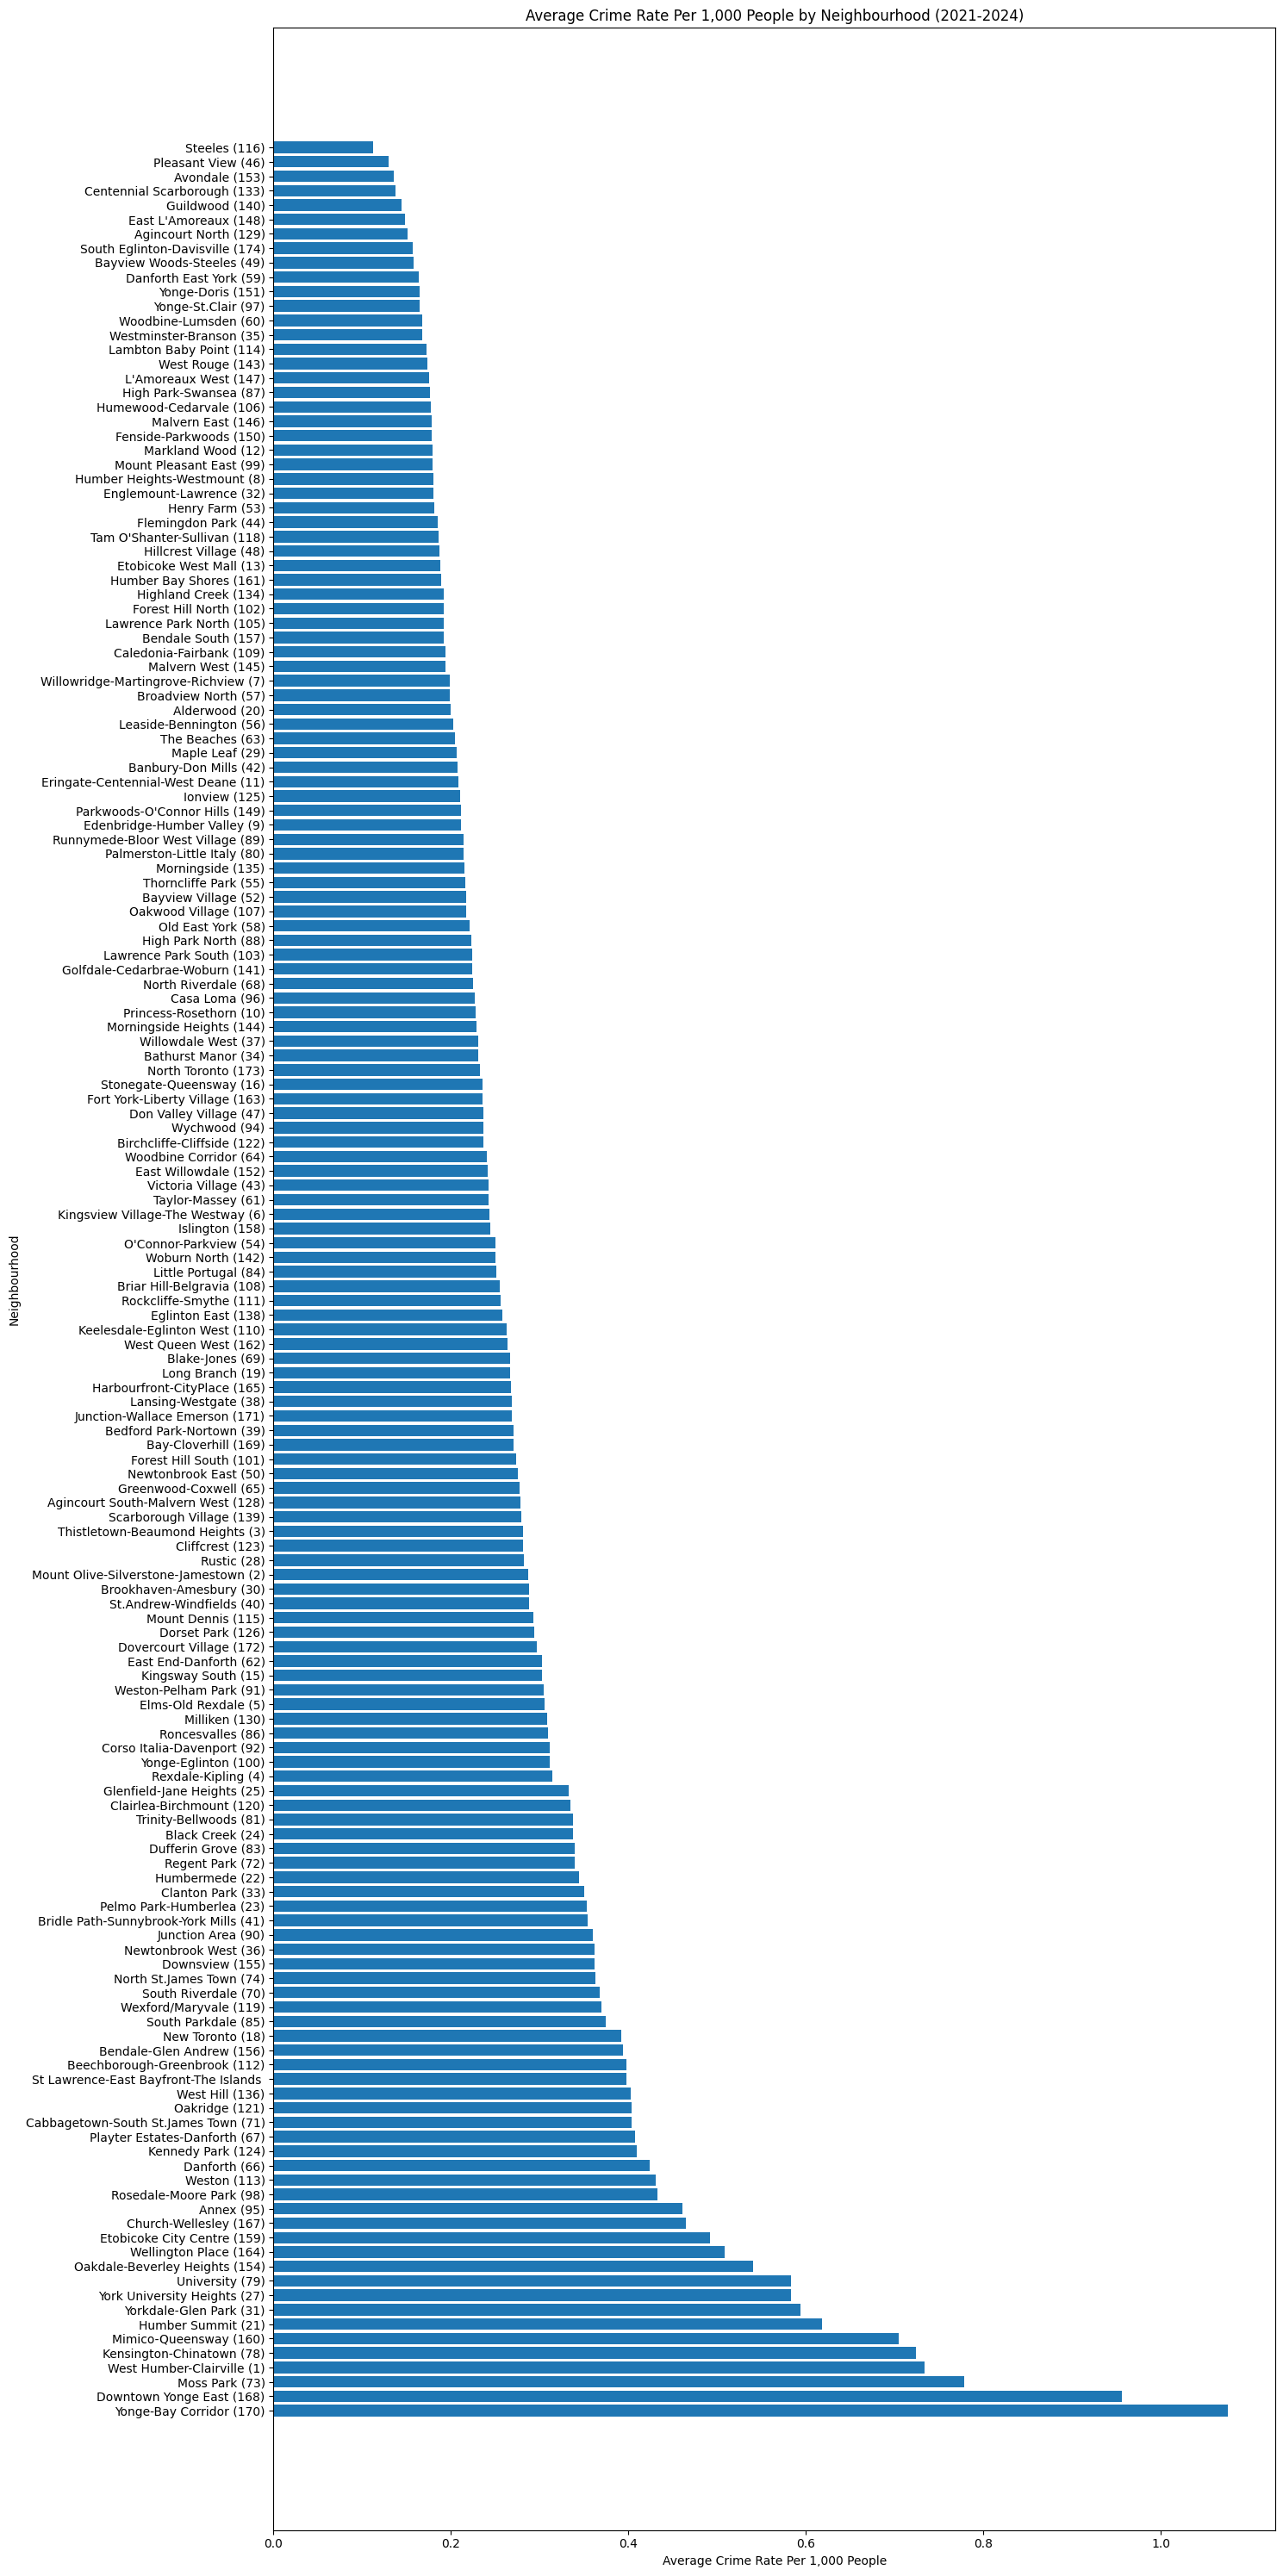

In [413]:
import matplotlib.pyplot as plt

# Group by HOOD_158 and calculate the average Crime_Rate_Per_1000
hood_crime_rate = df_crime_population.groupby('HOOD_158', observed=False)['Crime_Rate_Per_1000'].mean().reset_index()

# Merge with original dataframe to get NEIGHBOURHOOD_158 names
# Assuming df_mci is still available in the environment
hood_names = df_mci[['HOOD_158', 'NEIGHBOURHOOD_158']].drop_duplicates()
hood_crime_rate = hood_crime_rate.merge(hood_names, on='HOOD_158')


# Sort by Crime_Rate_Per_1000 in descending order
hood_crime_rate = hood_crime_rate.sort_values(by='Crime_Rate_Per_1000', ascending=False)

# Create the horizontal bar plot
plt.figure(figsize=(15, 30)) # Adjust figure size for horizontal plot
plt.barh(hood_crime_rate['NEIGHBOURHOOD_158'], hood_crime_rate['Crime_Rate_Per_1000']) # Use barh for horizontal bars
plt.xlabel('Average Crime Rate Per 1,000 People') # X-axis is now average crime rate
plt.ylabel('Neighbourhood') # Y-axis is now neighbourhoods
plt.title('Average Crime Rate Per 1,000 People by Neighbourhood (2021-2024)')
plt.tight_layout()
plt.show()

In [414]:
# prompt: calculate the annual crime rate for each category of crime for each neighbourhood. Add those results to a copy of df_mci where each crime occurence row has the year's crime rate for that neighbourhood added as a column

# Calculate annual crime rate for each category and neighbourhood
df_mci_occ['OCC_YEAR'] = df_mci_occ['OCC_DATE'].dt.year

annual_crime_rate = df_mci_occ.groupby(['HOOD_158', 'OCC_YEAR', 'MCI_CATEGORY']).size().reset_index(name='Annual_Crime_Count')

# Merge with population data
annual_crime_rate = annual_crime_rate.merge(
    df_population[['Neighbourhood Number', 'Population_2021']],
    left_on='HOOD_158',
    right_on='Neighbourhood Number',
    how='left'
)

# Drop the redundant 'Neighbourhood Number' column
annual_crime_rate = annual_crime_rate.drop('Neighbourhood Number', axis=1)

# Calculate the annual crime rate per 1,000 people
# Assuming population remains constant for 2021-2024 from 2021 data
annual_crime_rate['Annual_Crime_Rate_Per_1000'] = (annual_crime_rate['Annual_Crime_Count'] / annual_crime_rate['Population_2021']) * 1000

# Handle potential division by zero if population is 0 or NaN
annual_crime_rate['Annual_Crime_Rate_Per_1000'] = annual_crime_rate['Annual_Crime_Rate_Per_1000'].fillna(0)

# Display the calculated annual crime rate
display(annual_crime_rate.head())

# Create a copy of df_mci to add the crime rate column
df_mci_with_rate = df_mci_occ.copy()

# Merge the annual crime rate back into the original df_mci_occ DataFrame
# We need to merge on HOOD_158, OCC_YEAR, and MCI_CATEGORY
df_mci_with_rate = df_mci_with_rate.merge(
    annual_crime_rate[['HOOD_158', 'OCC_YEAR', 'MCI_CATEGORY', 'Annual_Crime_Rate_Per_1000']],
    on=['HOOD_158', 'OCC_YEAR', 'MCI_CATEGORY'],
    how='left' # Use left merge to keep all rows from df_mci_with_rate
)

# Display the first few rows of the updated DataFrame
display(df_mci_with_rate.head())

,HOOD_158,OCC_YEAR,MCI_CATEGORY,Annual_Crime_Count,Population_2021,Annual_Crime_Rate_Per_1000
0,001,2021,Assault,245,33300.0,7.357357
1,001,2021,Auto Theft,501,33300.0,15.045045
2,001,2021,Break and Enter,99,33300.0,2.972973
3,001,2021,Robbery,53,33300.0,1.591592
4,001,2021,Theft Over,57,33300.0,1.711712


,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,LONG_WGS84,LAT_WGS84,x,y,OCC_MONTH_SEQ,OCC_DAY_SEQ,OCC_WEEK_SEQ,HOLIDAY,WEEKEND,Annual_Crime_Rate_Per_1000
0,246908,GO-20212356161,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,6,...,-79.227042,43.834025,-8.819514e+06,5.439793e+06,1,0,1,0,0,3.047314
1,246910,GO-202117462,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,5,...,-79.446454,43.666724,-8.843939e+06,5.414011e+06,1,0,1,0,0,3.278689
2,246911,GO-202118202,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,8,...,-79.456852,43.655380,-8.845096e+06,5.412265e+06,1,0,1,0,0,1.279506
3,246912,GO-202119979,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,13,...,-79.351587,43.660222,-8.833378e+06,5.413010e+06,1,-1,0,0,1,1.725688
4,246913,GO-202113220,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,10,...,-79.471556,43.688058,-8.846733e+06,5.417295e+06,1,-1,0,0,1,0.087796



# **Summary of Changes:**
   1. Loaded and initially processed the crime data.
   2. Cleaned the data by removing partial weeks and unknown neighbourhoods.
   3. Aggregated weekly crime counts by neighbourhood and crime category.
   4. Identified the most common crime category ("Assault").
   5. Loaded and processed neighbourhood population data.
   6. Merged crime data with population data.
   7.  Calculated the crime rate per 1,000 people.
   8. Visualized the average crime rate per 1,000 people by neighbourhood.


## **Identify High-Risk Neighbourhoods based on Rate**

> Let's compare the list of neighbourhoods with the highest raw crime counts to those with the highest crime rates to see how normalization changed the ranking.

In [415]:
# Select the top 20 neighbourhoods by total raw crime counts
top_raw_crime = hood_crime_counts.head(20).reset_index(drop=True)

# Select the top 20 neighbourhoods by average crime rate per 1,000 people
top_crime_rate = hood_crime_rate.head(20).reset_index(drop=True)

# Display the two lists side-by-side for comparison
print("Top 20 Neighbourhoods by Total Raw Crime Counts (2021-2024)")
display(top_raw_crime[['NEIGHBOURHOOD_158', 'Crime_counts']])

print("\nTop 20 Neighbourhoods by Average Crime Rate Per 1,000 People (2021-2024)")
display(top_crime_rate[['NEIGHBOURHOOD_158', 'Crime_Rate_Per_1000']])

Top 20 Neighbourhoods by Total Raw Crime Counts (2021-2024)


,NEIGHBOURHOOD_158,Crime_counts
0,West Humber-Clairville (1),5079
1,Downtown Yonge East (168),3519
2,Moss Park (73),3480
3,York University Heights (27),3426
4,Yonge-Bay Corridor (170),2828
5,Annex (95),2808
6,Kensington-Chinatown (78),2728
7,Wellington Place (164),2705
8,St Lawrence-East Bayfront-The Islands,2590
9,Mimico-Queensway (160),2499



Top 20 Neighbourhoods by Average Crime Rate Per 1,000 People (2021-2024)


,NEIGHBOURHOOD_158,Crime_Rate_Per_1000
0,Yonge-Bay Corridor (170),1.07522
1,Downtown Yonge East (168),0.955834
2,Moss Park (73),0.778537
3,West Humber-Clairville (1),0.733281
4,Kensington-Chinatown (78),0.723807
5,Mimico-Queensway (160),0.704865
6,Humber Summit (21),0.617878
7,Yorkdale-Glen Park (31),0.594274
8,York University Heights (27),0.582947
9,University (79),0.582751




> **Point of Interest:**
>
> * "West Humber-Clairville (1)" is ranked #1 by total raw crime counts but drops to #4 when considering the crime rate per 1,000 people.
> * Conversely, "Yonge-Bay Corridor (170)" is ranked #5 by raw counts but jumps to #1 in terms of crime rate.



# Task
Analyze crime rates by category and crime rate trends over time using the provided data.

## Normalize crime rates by category

### Subtask:
Merge the crime counts by neighbourhood, week, and category with the population data, calculate crime rates by category per neighbourhood per week, and then aggregate to get the average crime rate per category per neighbourhood. Visualize the results.


**Reasoning**:
Merge the crime counts by neighbourhood, week, and category with the population data, calculate crime rates by category per neighbourhood per week, aggregate to get the average crime rate per category per neighbourhood, and then visualize the results for each crime category.



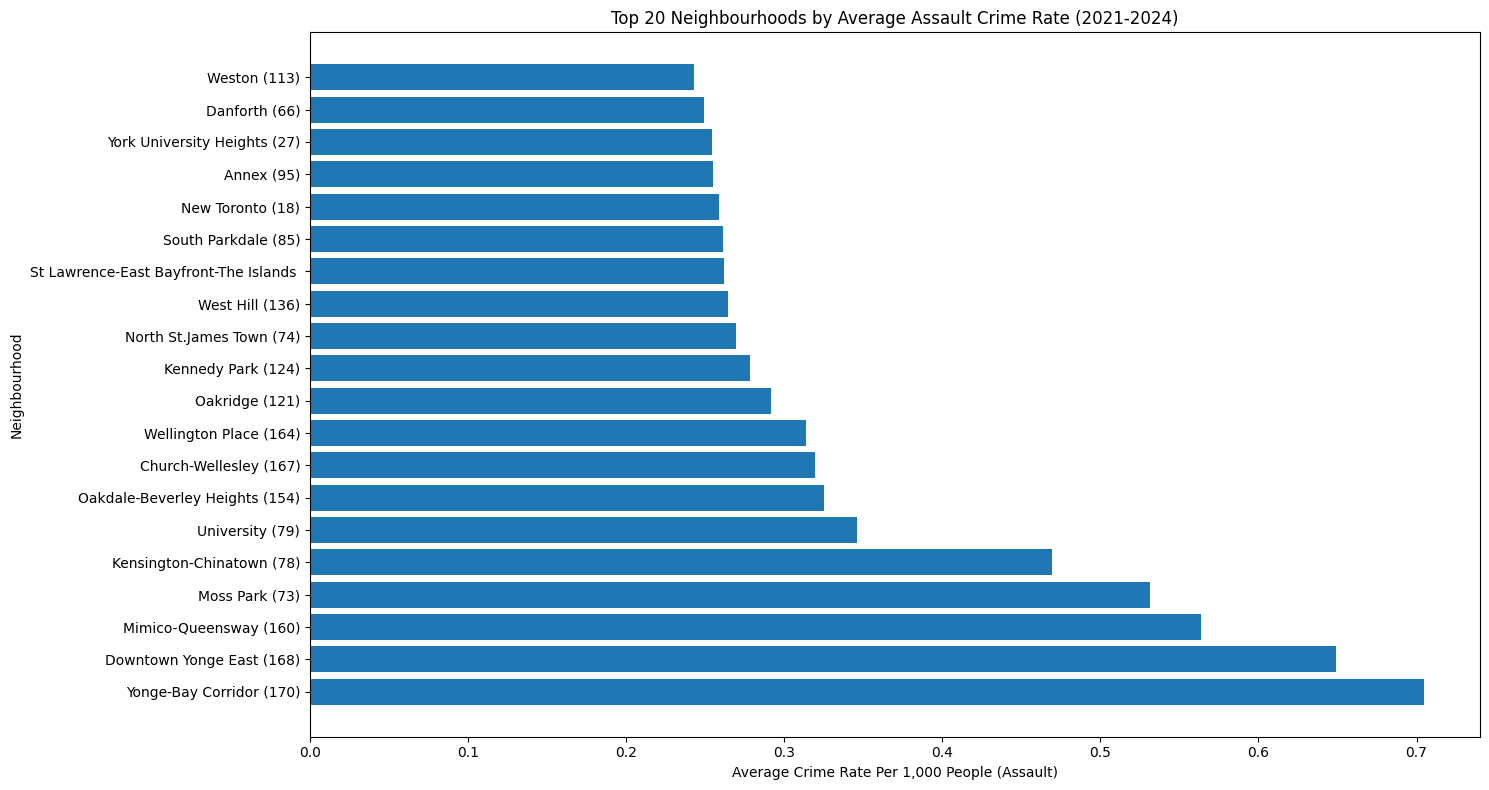

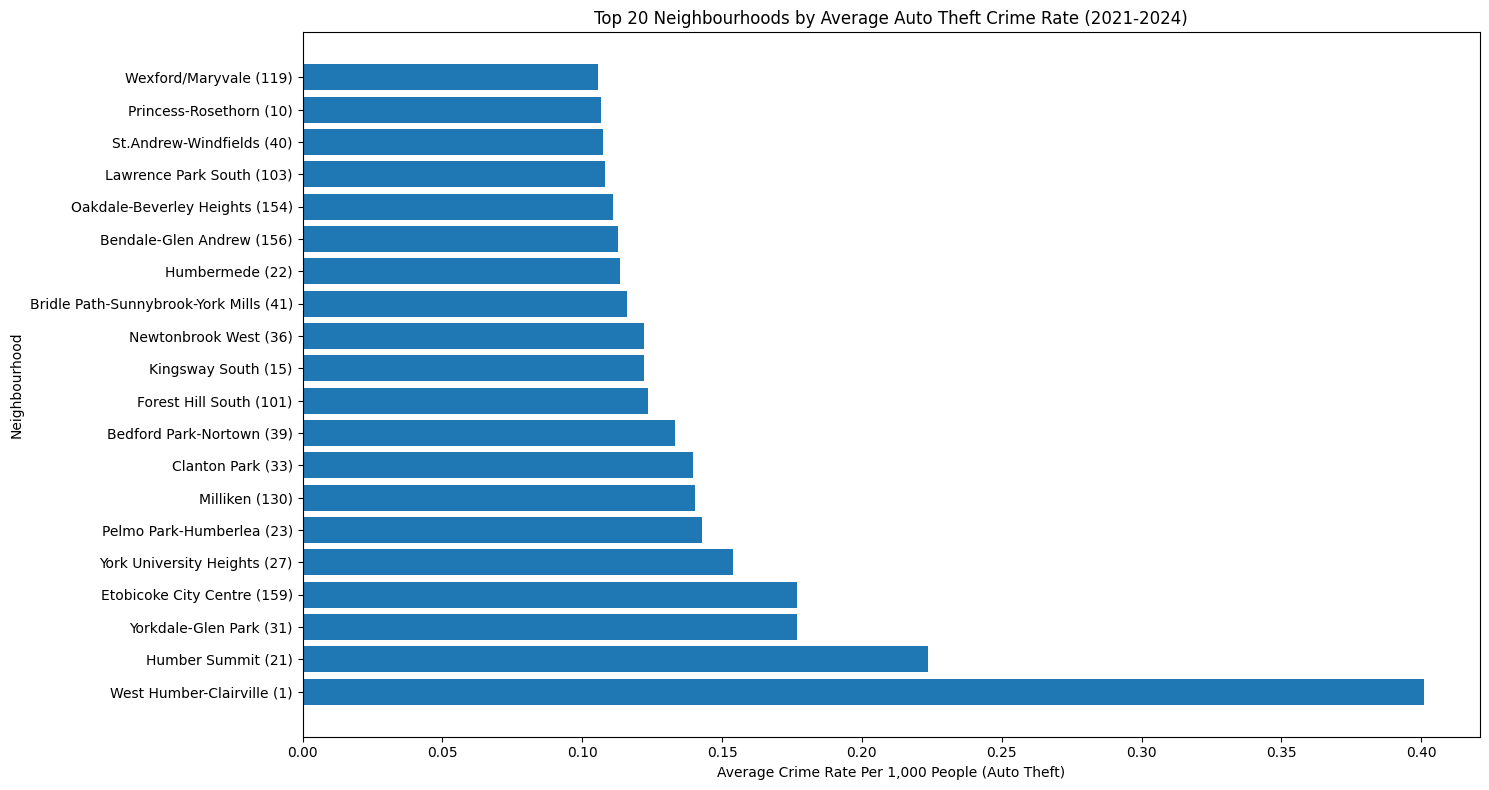

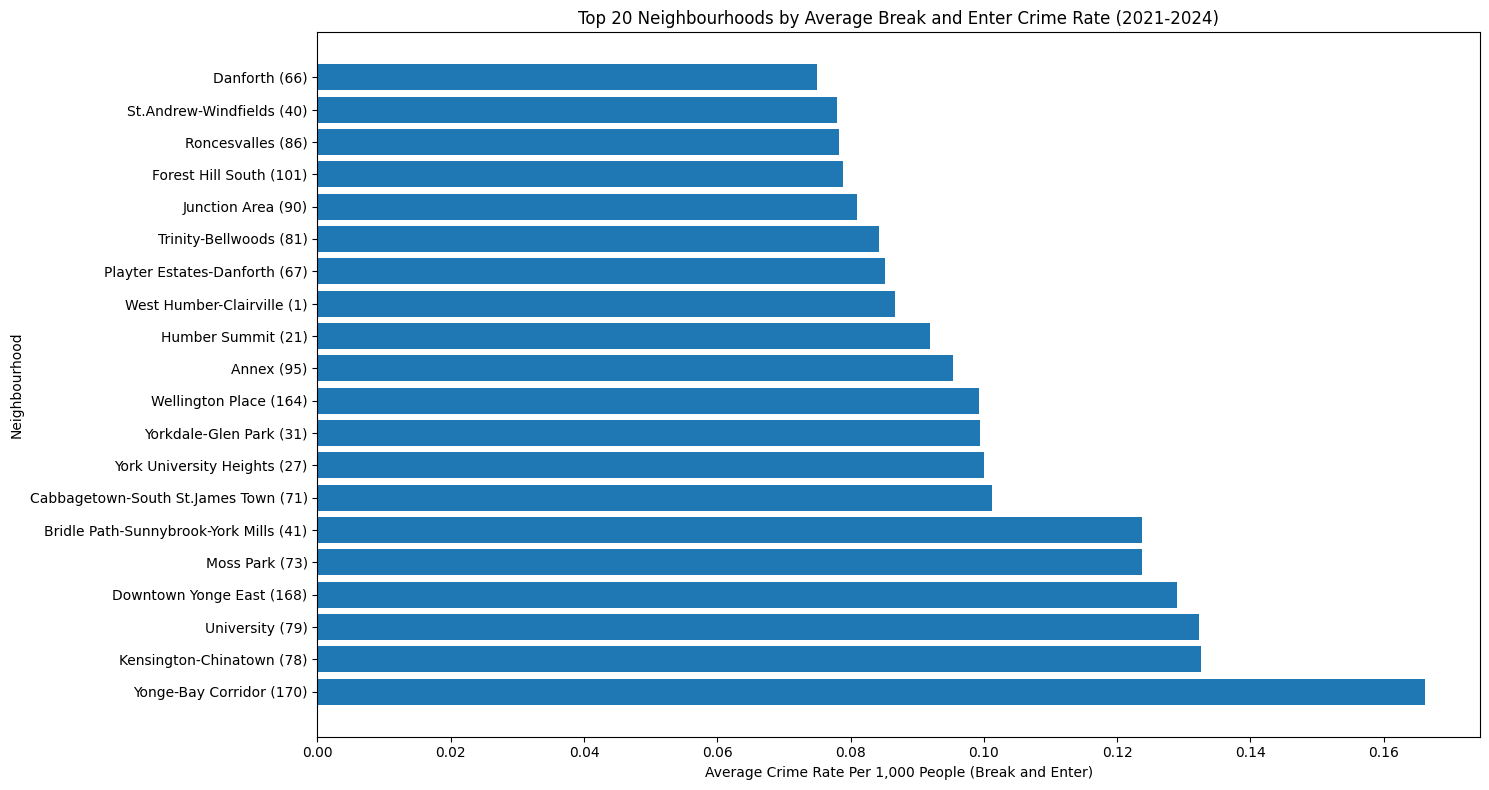

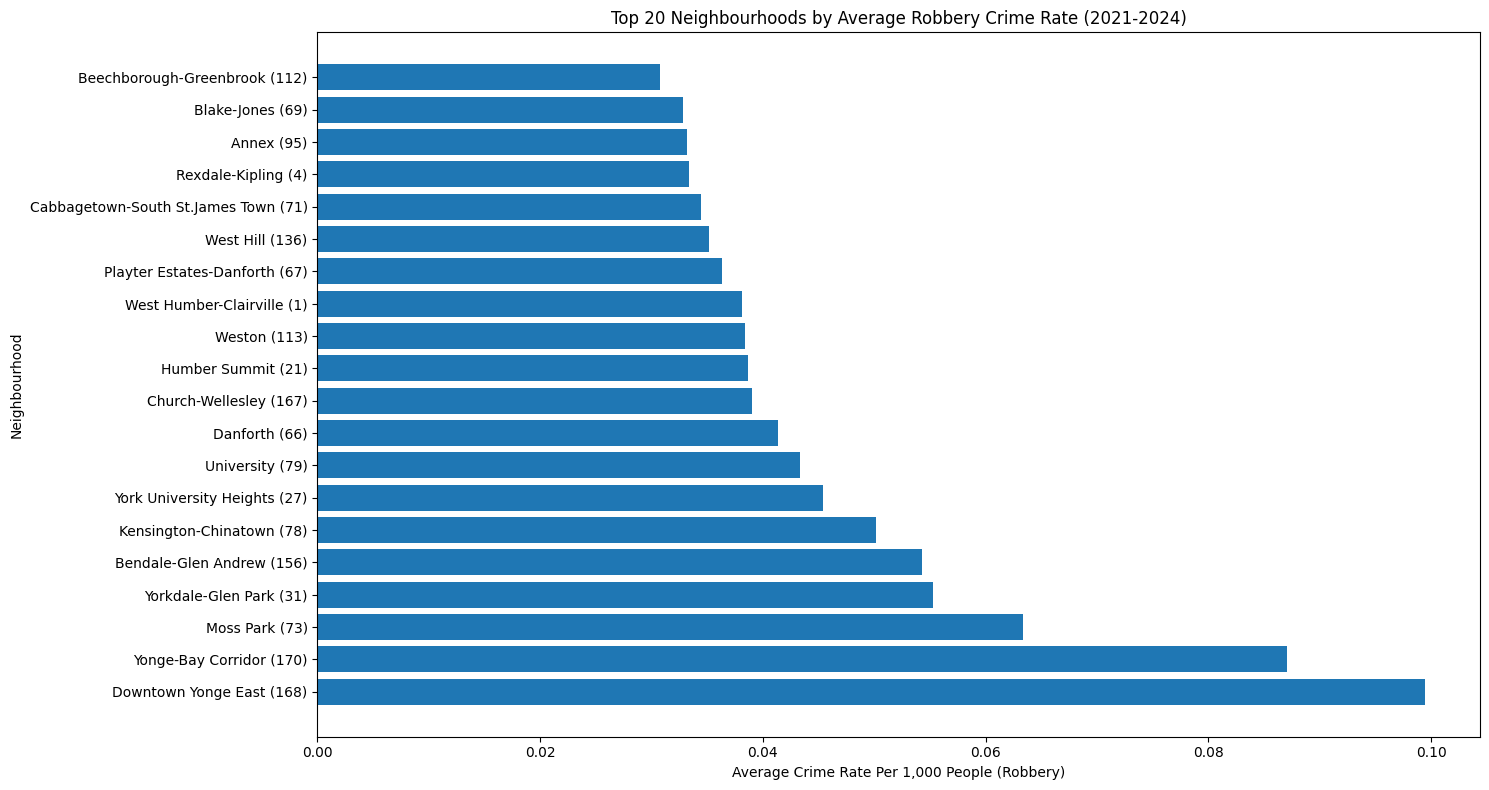

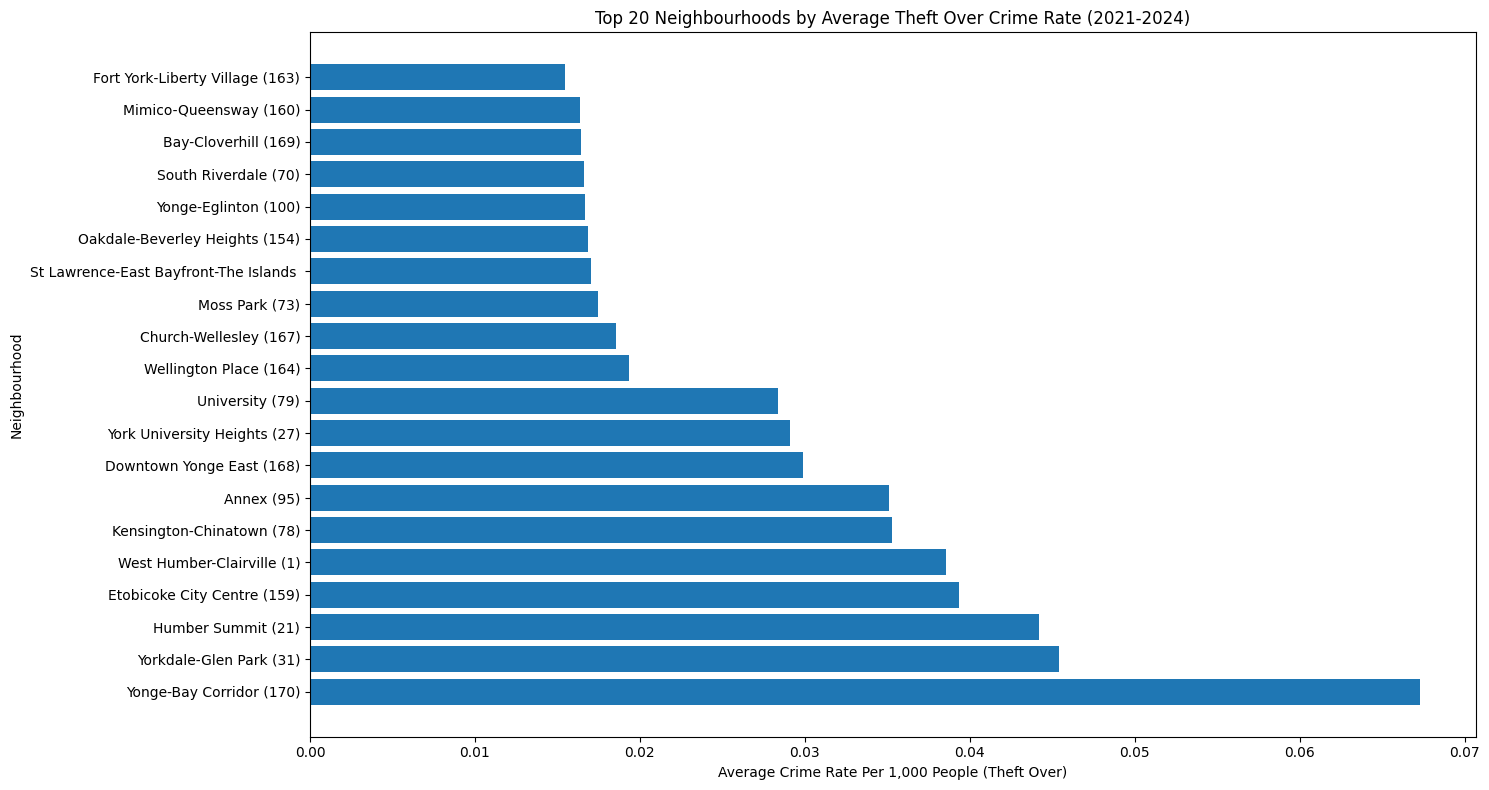

In [416]:
# Merge the grouped_counts_mci_categories_with_zeros_short with df_population
df_crime_population_category = grouped_counts_mci_categories_with_zeros_short.merge(
    df_population,
    left_on='HOOD_158',
    right_on='Neighbourhood Number',
    how='inner'
)

# Drop the redundant 'Neighbourhood Number' column
df_crime_population_category = df_crime_population_category.drop('Neighbourhood Number', axis=1)

# Calculate the crime rate per 1,000 people for each crime category per neighbourhood per week
df_crime_population_category['Crime_Rate_Category_Per_1000'] = (df_crime_population_category['Crime_counts'] / df_crime_population_category['Population_2021']) * 1000

# Group by neighbourhood and crime category and calculate the mean crime rate
average_crime_rate_category = df_crime_population_category.groupby(['HOOD_158', 'MCI_CATEGORY'], observed=False)['Crime_Rate_Category_Per_1000'].mean().reset_index()

# Merge with hood_names to get neighbourhood names
hood_names = df_mci[['HOOD_158', 'NEIGHBOURHOOD_158']].drop_duplicates()
average_crime_rate_category = average_crime_rate_category.merge(hood_names, on='HOOD_158')

# Get unique crime categories
unique_categories = average_crime_rate_category['MCI_CATEGORY'].unique()

# Iterate through each crime category and create a bar plot
for category in unique_categories:
    # Filter data for the current category
    category_data = average_crime_rate_category[average_crime_rate_category['MCI_CATEGORY'] == category]

    # Sort by average crime rate in descending order and select top 20
    top_neighborhoods_category = category_data.sort_values(by='Crime_Rate_Category_Per_1000', ascending=False).head(20)

    # Create a horizontal bar plot for the top 20 neighbourhoods
    plt.figure(figsize=(15, 8))
    plt.barh(top_neighborhoods_category['NEIGHBOURHOOD_158'], top_neighborhoods_category['Crime_Rate_Category_Per_1000'])
    plt.xlabel(f'Average Crime Rate Per 1,000 People ({category})')
    plt.ylabel('Neighbourhood')
    plt.title(f'Top 20 Neighbourhoods by Average {category} Crime Rate (2021-2024)')
    plt.tight_layout()
    plt.show()

## Analyze overall crime rate trends

### Subtask:
Aggregate the overall crime rate per neighbourhood per week by week to get the overall crime rate trend over time. Visualize the trend.


**Reasoning**:
Group the data by week and calculate the mean crime rate, then create a line plot to visualize the trend.



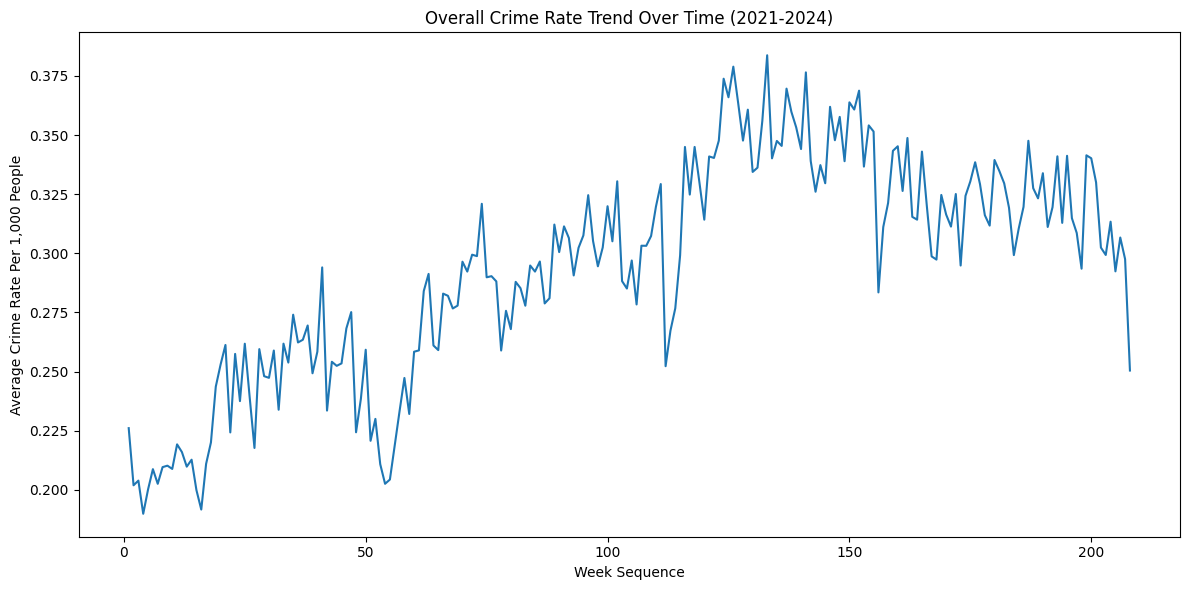

In [417]:
import matplotlib.pyplot as plt

# Group by WEEK_SEQ and calculate the mean of Crime_Rate_Per_1000
overall_crime_trend = df_crime_population.groupby('WEEK_SEQ', observed=False)['Crime_Rate_Per_1000'].mean().reset_index()

# Create a line plot
plt.figure(figsize=(12, 6))
plt.plot(overall_crime_trend['WEEK_SEQ'], overall_crime_trend['Crime_Rate_Per_1000'])

# Add title and labels
plt.title('Overall Crime Rate Trend Over Time (2021-2024)')
plt.xlabel('Week Sequence')
plt.ylabel('Average Crime Rate Per 1,000 People')

# Display the plot
plt.tight_layout()
plt.show()

## Analyze neighbourhood crime rate trends

### Subtask:
Analyze and visualize the crime rate trends over time for specific neighbourhoods of interest.


**Reasoning**:
Identify interesting neighbourhoods from previous analysis, filter the dataframe for these neighbourhoods, group by week and calculate the average crime rate per 1000 people, and then generate line plots for each selected neighbourhood to visualize their crime rate trends over time.



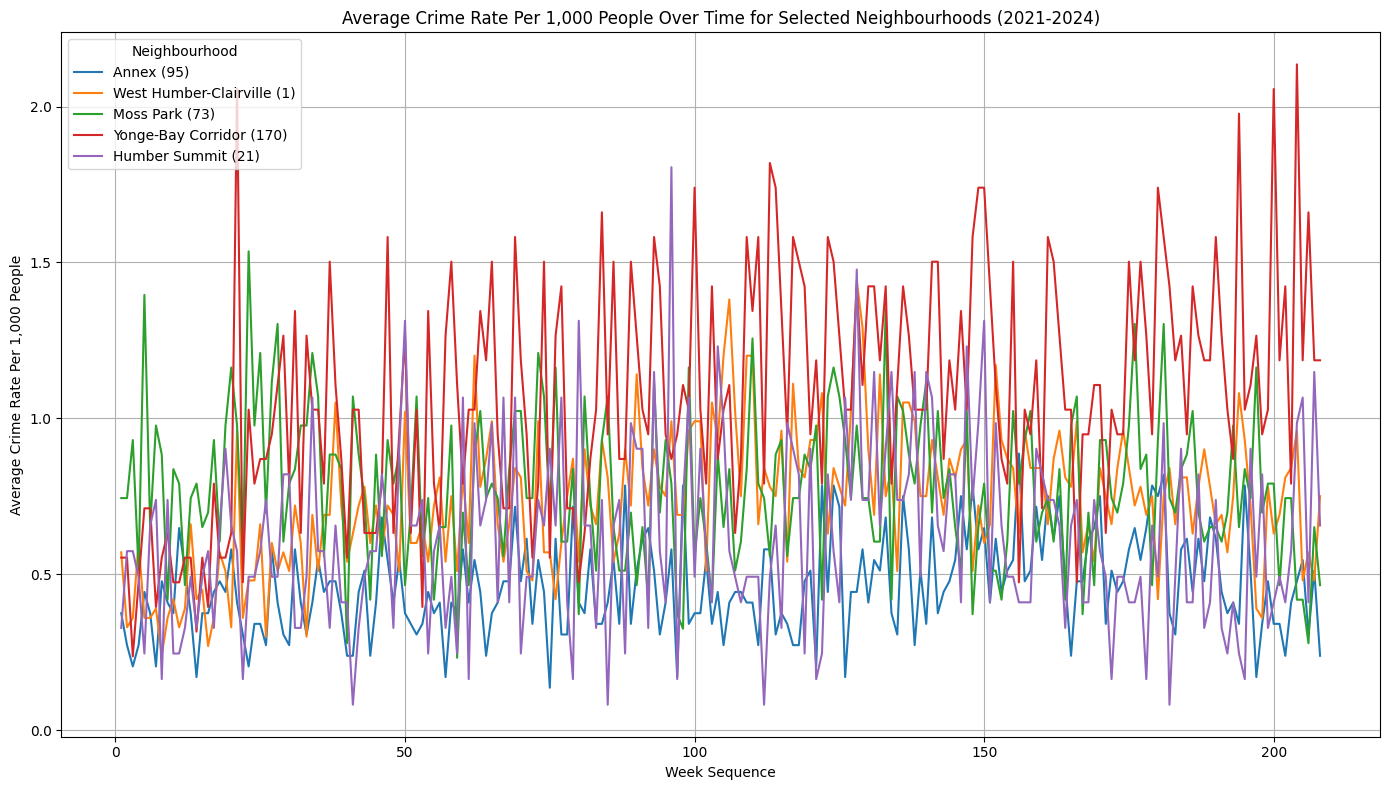

In [418]:
import matplotlib.pyplot as plt

# 1. Identify a few neighbourhoods of interest from the previous analysis.
# Based on the previous analysis, we can select neighborhoods that appeared
# in the top lists for either raw crime counts or crime rate, or both.
# Let's pick a few diverse examples:
# - West Humber-Clairville (1): High raw count, drops in rate.
# - Yonge-Bay Corridor (170): Jumps to high rate from raw count.
# - Moss Park (73): High in both lists.
# - Annex (95): High in raw count, lower in rate.
# - Humber Summit (21): Appears in top crime rate but not top raw count.
selected_hood_codes = ['001', '170', '073', '095', '021']

# Merge with hood_names to get neighbourhood names for the selected codes
hood_names = df_mci[['HOOD_158', 'NEIGHBOURHOOD_158']].drop_duplicates()
selected_hood_names = hood_names[hood_names['HOOD_158'].isin(selected_hood_codes)]

# 2. Filter the df_crime_population DataFrame to include data only for the selected neighbourhoods.
df_selected_crime_population = df_crime_population[df_crime_population['HOOD_158'].isin(selected_hood_codes)].copy()

# 3. For each selected neighbourhood, group the filtered data by WEEK_SEQ and calculate the mean Crime_Rate_Per_1000.
# This step is not strictly necessary if we plot directly from df_selected_crime_population
# as it already has the weekly crime rate per neighbourhood. We can plot directly.

# 4. Create a line plot for each selected neighbourhood showing its average crime rate over time (WEEK_SEQ).
# We can use a single figure with multiple lines, or separate figures.
# Let's use a single figure for comparison.

plt.figure(figsize=(14, 8))

for index, row in selected_hood_names.iterrows():
    hood_code = row['HOOD_158']
    hood_name = row['NEIGHBOURHOOD_158']

    # Filter data for the current neighbourhood
    hood_data = df_selected_crime_population[df_selected_crime_population['HOOD_158'] == hood_code]

    # Plot the crime rate trend
    plt.plot(hood_data['WEEK_SEQ'], hood_data['Crime_Rate_Per_1000'], label=hood_name)


# 5. Ensure that the plots are clearly titled and have appropriate axis labels.
plt.title('Average Crime Rate Per 1,000 People Over Time for Selected Neighbourhoods (2021-2024)')
plt.xlabel('Week Sequence')
plt.ylabel('Average Crime Rate Per 1,000 People')
plt.legend(title='Neighbourhood')
plt.grid(True)

# 6. Display the plots.
plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

*   For the crime categories analyzed (Assault, Break and Enter, Robbery, Theft Over, and Auto Theft), the top 20 neighbourhoods with the highest average crime rates per 1,000 people were identified and visualized.
*   The overall crime rate trend across all neighbourhoods showed fluctuations over the period from 2021 to 2024.
*   Analyzing specific neighbourhoods (West Humber-Clairville, Yonge-Bay Corridor, Moss Park, Annex, and Humber Summit) revealed distinct patterns and trends in their average crime rates over time, highlighting variations in how crime rates evolved in different areas.

### Insights or Next Steps

*   Investigate specific events or seasonal patterns that might explain the observed fluctuations in the overall crime rate trend and the trends in individual neighbourhoods.
*   Further analyze the top neighbourhoods identified for each crime category to understand potential underlying factors contributing to higher crime rates in those areas.
